## **설정**

In [1]:
## Google Drive Amount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
## Import libaries
import pandas as pd
import numpy as np

import os

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!pip install gdown

In [4]:
import gdown

# Create a directory to store downloaded files
import os
download_dir = './gdrive_data'
os.makedirs(download_dir, exist_ok=True)

def download_and_read_csv(url_path, filename):
    """Downloads a file from Google Drive URL and reads it into a pandas DataFrame."""
    local_filepath = os.path.join(download_dir, filename)
    print(f"Downloading {filename} from {url_path}...")
    gdown.download(url_path, local_filepath, quiet=False)
    print(f"Reading {local_filepath}...")
    return pd.read_csv(local_filepath)

In [5]:
## Setting
# base_path = '/content/drive/MyDrive/CS/'

## **데이터 불러오기**

In [6]:
# '00_predData' -> '01_CatBoost_M5020_F2020'

url_2018="https://drive.google.com/file/d/11PJ9siadM1t57z9Wqg5x6ZOecyrnZUbs/view?usp=drive_link"
path_2018='https://drive.google.com/uc?id='+url_2018.split('/')[-2] + '&confirm=t'

url_2019="https://drive.google.com/file/d/17VCp9yeqVGAAsMNr4F_G-a65s-yhgwHG/view?usp=drive_link"
path_2019='https://drive.google.com/uc?id='+url_2019.split('/')[-2] + '&confirm=t'

url_2020="https://drive.google.com/file/d/1jtWZJVDvJJDQOyr0J6zI3xg1D12XwMnC/view?usp=drive_link"
path_2020='https://drive.google.com/uc?id='+url_2020.split('/')[-2] + '&confirm=t'

url_2021="https://drive.google.com/file/d/1NMgfLaa6ez1VTXzOqk3XJmswA_TqbFmo/view?usp=drive_link"
path_2021='https://drive.google.com/uc?id='+url_2021.split('/')[-2] + '&confirm=t'


## Load the data
# 1. Prediction Result : ticker, date, permno, pred_ret, true_ret
result_2018 = download_and_read_csv(path_2018, 'result_2018.csv')
result_2019 = download_and_read_csv(path_2019, 'result_2019.csv')
result_2020 = download_and_read_csv(path_2020, 'result_2020.csv')
result_2021 = download_and_read_csv(path_2021, 'result_2021.csv')

Downloading...
From: https://drive.google.com/uc?id=11PJ9siadM1t57z9Wqg5x6ZOecyrnZUbs&confirm=t
To: /content/gdrive_data/result_2018.csv
100%|██████████| 748k/748k [00:00<00:00, 32.3MB/s]


Reading ./gdrive_data/result_2018.csv...


Downloading...
From: https://drive.google.com/uc?id=17VCp9yeqVGAAsMNr4F_G-a65s-yhgwHG&confirm=t
To: /content/gdrive_data/result_2019.csv
100%|██████████| 751k/751k [00:00<00:00, 33.5MB/s]


Reading ./gdrive_data/result_2019.csv...


Downloading...
From: https://drive.google.com/uc?id=1jtWZJVDvJJDQOyr0J6zI3xg1D12XwMnC&confirm=t
To: /content/gdrive_data/result_2020.csv
100%|██████████| 747k/747k [00:00<00:00, 22.6MB/s]


Reading ./gdrive_data/result_2020.csv...


Downloading...
From: https://drive.google.com/uc?id=1NMgfLaa6ez1VTXzOqk3XJmswA_TqbFmo&confirm=t
To: /content/gdrive_data/result_2021.csv
100%|██████████| 748k/748k [00:00<00:00, 26.9MB/s]

Reading ./gdrive_data/result_2021.csv...


In [7]:
# 2. Firm Top 1000 데이터
# '00_ourData' -> 'firm_top1000.csv'
url_firm="https://drive.google.com/file/d/1qMv0DwZnGss9TlNkTA7n3Jd75MVnz0gK/view?usp=drive_link"
path_firm='https://drive.google.com/uc?id='+url_firm.split('/')[-2] + '&confirm=t'

firm_top1000 = download_and_read_csv(path_firm, 'firm_top1000.csv')


# 3. macroeco 데이터
# '00_ourData' -> 'macroeco_data.csv'
url_macro="https://drive.google.com/file/d/1Di3t5edEAFBKlCpJGJdVahB1MNJ3Xor9/view?usp=drive_link"
path_macro='https://drive.google.com/uc?id='+url_macro.split('/')[-2] + '&confirm=t'

macroeco = download_and_read_csv(path_macro, 'macroeco_data.csv')

Downloading...
From: https://drive.google.com/uc?id=1qMv0DwZnGss9TlNkTA7n3Jd75MVnz0gK&confirm=t
To: /content/gdrive_data/firm_top1000.csv
100%|██████████| 288M/288M [00:02<00:00, 138MB/s]


Reading ./gdrive_data/firm_top1000.csv...


Downloading...
From: https://drive.google.com/uc?id=1Di3t5edEAFBKlCpJGJdVahB1MNJ3Xor9&confirm=t
To: /content/gdrive_data/macroeco_data.csv
100%|██████████| 322k/322k [00:00<00:00, 15.3MB/s]

Reading ./gdrive_data/macroeco_data.csv...


## **데이터 병합**

In [8]:
df_all = pd.concat([result_2018, result_2019, result_2020, result_2021], axis=0)
df_all.reset_index(drop=True, inplace=True)

df_all['date'] = pd.to_datetime(df_all['date'])
df_all['Year'] = df_all['date'].dt.year
df_all['Month'] = df_all['date'].dt.month

print(f"전체 데이터 크기: {df_all.shape}")

전체 데이터 크기: (46243, 8)


### **시가 총액**

In [9]:
# 병합을 위한 임시 데이터
temp_me = firm_top1000[['permno', 'date', 'me']].copy()
temp_me['date'] = pd.to_datetime(temp_me['date'])
temp_me['Year'] = temp_me['date'].dt.year
temp_me['Month'] = temp_me['date'].dt.month
temp_me.drop(['date'], axis=1, inplace=True)

In [10]:
# 병합
df_all_with_me = pd.merge(df_all, temp_me, on=['permno','Year', 'Month'], how='left')
df_all_with_me.drop(['Year', 'Month', 'Unnamed: 0'], axis=1, inplace=True)

In [11]:
df_all_with_me

,ticker,date,pred_ret,true_ret,permno,me
0,AAL,2018-01-31,0.023058,0.044013,21020,2.474068e+07
1,PNW,2018-01-31,0.015580,-0.053240,27991,9.517161e+06
2,AAN,2018-01-31,0.018414,0.026098,10517,2.819905e+06
3,ABT,2018-01-31,0.017164,0.094095,20482,9.933610e+07
4,AMD,2018-01-31,0.022712,0.336576,61241,9.940760e+06
...,...,...,...,...,...,...
46238,CBRE,2021-12-31,-0.007115,0.135398,90199,3.198403e+07
46239,ALNY,2021-12-31,0.017256,-0.077367,90178,2.198266e+07
46240,ESI,2021-12-31,0.010898,0.061653,14406,5.660394e+06
46241,APG,2021-12-31,0.009242,0.105534,19317,5.236009e+06


In [12]:
df_all_with_me.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46243 entries, 0 to 46242
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   ticker    46243 non-null  object        
 1   date      46243 non-null  datetime64[ns]
 2   pred_ret  46243 non-null  float64       
 3   true_ret  46243 non-null  float64       
 4   permno    46243 non-null  int64         
 5   me        46243 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 2.1+ MB


## **beta 계수**

### **필요한 데이터 병합**

In [13]:
temp_f = firm_top1000[['date', 'ticker', 'mom1m']].copy()

temp_f['mom1m'] = 100*temp_f['mom1m']

temp_f['date'] = pd.to_datetime(temp_f['date'])
temp_f['Year'] = temp_f['date'].dt.year
temp_f['Month'] = temp_f['date'].dt.month

In [14]:
temp_m = macroeco[['sasdate', 'S&P 500']].copy()

temp_m['dSP500'] = temp_m['S&P 500'].pct_change()

temp_m['date'] = pd.to_datetime(temp_m['sasdate'])
temp_m['Year'] = temp_m['date'].dt.year
temp_m['Month'] = temp_m['date'].dt.month
temp_m = temp_m[['Year', 'Month', 'dSP500']]

In [15]:
temp_fm = pd.merge(temp_f, temp_m, on=['Year', 'Month'], how='left')
# temp_fm = temp_fm[['date', 'Year', 'Month', 'mom1m','S&P 500', 'dSP500']]

In [16]:
temp_fm.head()

,date,ticker,mom1m,Year,Month,dSP500
0,1996-08-31,AAA,-7.692308,1996,8,0.028894
1,1996-09-30,AAA,16.666667,1996,9,0.018410
2,1996-10-31,AAA,-16.666667,1996,10,0.039385
3,1996-11-30,AAA,-11.428571,1996,11,0.048770
4,1996-12-31,AAA,-6.451613,1996,12,0.010304


### **Rolling OLS**

In [17]:
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

In [18]:
# -----------------------------------------------------------
# 롤링 지표 계산 함수 (종목별 적용)
# -----------------------------------------------------------
def calculate_rolling_metrics(group):
    # 윈도우 설정 (60개월, 최소 30개월)
    window = 60
    min_periods = 30

    # 시장 수익률의 분산 (Var(Rm))
    # 시장 변동성은 모든 종목에 동일하지만, 윈도우 계산을 위해 여기서 같이 구함
    rolling_mkt_var = group['dSP500'].rolling(window=window, min_periods=min_periods).var()

    # 공분산 (Cov(Ri, Rm))
    rolling_cov = group['mom1m'].rolling(window=window, min_periods=min_periods).cov(group['dSP500'])

    # 개별 주식의 분산 (Var(Ri))
    rolling_stock_var = group['mom1m'].rolling(window=window, min_periods=min_periods).var()


    # --- 지표 산출 ---
    # 베타 (Beta = Cov / Var_mkt)
    group['Beta'] = rolling_cov / rolling_mkt_var

    # 시장 변동성 (Market Volatility = sqrt(Var_mkt))
    group['Mkt_Vol'] = np.sqrt(rolling_mkt_var)

    # 잔차 변동성 (Idiosyncratic Volatility)
    # 공식: Var(e) = Var(Ri) - Beta^2 * Var(Rm)
    # 이론적으로는 양수여야 하나, 부동소수점 오차로 아주 작은 음수가 나올 수 있어 처리 필요
    idio_var = rolling_stock_var - (group['Beta']**2 * rolling_mkt_var)
    group['Idio_Vol'] = np.sqrt(idio_var.clip(lower=0)) # 음수는 0으로 처리 후 루트

    # [핵심] Shift(1) 적용 (Leakage 방지)
    # 계산된 값은 해당 월까지의 데이터이므로, 다음 달 예측을 위해 한 칸 내림
    cols_to_shift = ['Beta', 'Mkt_Vol', 'Idio_Vol']
    group[cols_to_shift] = group[cols_to_shift].shift(1)

    return group

In [19]:
# -----------------------------------------------------------
# 그룹별 적용 및 필터링
# -----------------------------------------------------------
# 종목(ticker)별로 함수 적용
# sort_values로 날짜 정렬을 보장한 후 적용해야 함
temp_fm = temp_fm.sort_values(['ticker', 'date'])
temp_fm = temp_fm.groupby('ticker', group_keys=False).apply(calculate_rolling_metrics)

# 기간 필터링 (2018년 예측을 위해 2013~2017 데이터가 쓰였으므로, 결과물은 2018부터 봐도 됨)
# 2013~2021 범위 유지
temp_fm_filtered = temp_fm[(temp_fm['Year'] >= 2013) & (temp_fm['Year'] <= 2021)].copy()

/tmp/ipython-input-2263354065.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp_fm = temp_fm.groupby('ticker', group_keys=False).apply(calculate_rolling_metrics)


In [20]:
# 결과 확인
print(temp_fm_filtered[['date', 'ticker', 'Beta', 'Mkt_Vol', 'Idio_Vol']].head())

             date ticker        Beta   Mkt_Vol   Idio_Vol
181113 2013-01-31      A  113.315258  0.049680  10.044192
181114 2013-02-28      A  115.911969  0.049118  10.031599
181115 2013-03-31      A  115.812649  0.049109  10.028295
181116 2013-04-30      A  112.518566  0.049021  10.087705
181117 2013-05-31      A  114.548178  0.048799  10.034958


In [21]:
temp_fm_filtered

,date,ticker,mom1m,Year,Month,dSP500,Beta,Mkt_Vol,Idio_Vol
181113,2013-01-31,A,7.182026,2013,1,0.040857,113.315258,0.049680,10.044192
181114,2013-02-28,A,9.379581,2013,2,0.021555,115.911969,0.049118,10.031599
181115,2013-03-31,A,-7.369360,2013,3,0.025471,115.812649,0.049109,10.028295
181116,2013-04-30,A,1.470592,2013,4,0.012812,112.518566,0.049021,10.087705
181117,2013-05-31,A,-1.262813,2013,5,0.044019,114.548178,0.048799,10.034958
...,...,...,...,...,...,...,...,...,...
285426,2021-08-31,ZTS,8.902123,2021,8,0.020739,19.288607,0.036224,5.122393
285427,2021-09-30,ZTS,0.917613,2021,9,-0.001946,19.908492,0.036239,5.162407
285428,2021-10-31,ZTS,-5.093859,2021,10,0.003412,19.920539,0.036178,5.164082
285429,2021-11-30,ZTS,11.491705,2021,11,0.046333,20.754273,0.036108,5.252256


In [22]:
# 위의 temp_fm_filtered + me, S&P500, pred_ret, true_ret,permno 추가해야함.

In [23]:
df_all_with_me

,ticker,date,pred_ret,true_ret,permno,me
0,AAL,2018-01-31,0.023058,0.044013,21020,2.474068e+07
1,PNW,2018-01-31,0.015580,-0.053240,27991,9.517161e+06
2,AAN,2018-01-31,0.018414,0.026098,10517,2.819905e+06
3,ABT,2018-01-31,0.017164,0.094095,20482,9.933610e+07
4,AMD,2018-01-31,0.022712,0.336576,61241,9.940760e+06
...,...,...,...,...,...,...
46238,CBRE,2021-12-31,-0.007115,0.135398,90199,3.198403e+07
46239,ALNY,2021-12-31,0.017256,-0.077367,90178,2.198266e+07
46240,ESI,2021-12-31,0.010898,0.061653,14406,5.660394e+06
46241,APG,2021-12-31,0.009242,0.105534,19317,5.236009e+06


In [24]:
temp_fm_filtered

,date,ticker,mom1m,Year,Month,dSP500,Beta,Mkt_Vol,Idio_Vol
181113,2013-01-31,A,7.182026,2013,1,0.040857,113.315258,0.049680,10.044192
181114,2013-02-28,A,9.379581,2013,2,0.021555,115.911969,0.049118,10.031599
181115,2013-03-31,A,-7.369360,2013,3,0.025471,115.812649,0.049109,10.028295
181116,2013-04-30,A,1.470592,2013,4,0.012812,112.518566,0.049021,10.087705
181117,2013-05-31,A,-1.262813,2013,5,0.044019,114.548178,0.048799,10.034958
...,...,...,...,...,...,...,...,...,...
285426,2021-08-31,ZTS,8.902123,2021,8,0.020739,19.288607,0.036224,5.122393
285427,2021-09-30,ZTS,0.917613,2021,9,-0.001946,19.908492,0.036239,5.162407
285428,2021-10-31,ZTS,-5.093859,2021,10,0.003412,19.920539,0.036178,5.164082
285429,2021-11-30,ZTS,11.491705,2021,11,0.046333,20.754273,0.036108,5.252256


In [25]:
# 날짜 형식 통일
df_all_with_me['date'] = pd.to_datetime(df_all_with_me['date'])
temp_fm_filtered['date'] = pd.to_datetime(temp_fm_filtered['date'])

# temp_fm_filtered에서 가져올 컬럼: date, ticker, Beta, Mkt_Vol, Idio_Vol
risk_metrics = temp_fm_filtered[['date', 'ticker', 'dSP500', 'Beta', 'Mkt_Vol', 'Idio_Vol']]

In [26]:
final_df = pd.merge(
    risk_metrics,
    df_all_with_me,
    on=['date', 'ticker'],
    how='left'
)

In [27]:
final_df

,date,ticker,dSP500,Beta,Mkt_Vol,Idio_Vol,pred_ret,true_ret,permno,me
0,2013-01-31,A,0.040857,113.315258,0.049680,10.044192,NaN,NaN,NaN,NaN
1,2013-02-28,A,0.021555,115.911969,0.049118,10.031599,NaN,NaN,NaN,NaN
2,2013-03-31,A,0.025471,115.812649,0.049109,10.028295,NaN,NaN,NaN,NaN
3,2013-04-30,A,0.012812,112.518566,0.049021,10.087705,NaN,NaN,NaN,NaN
4,2013-05-31,A,0.044019,114.548178,0.048799,10.034958,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
104353,2021-08-31,ZTS,0.020739,19.288607,0.036224,5.122393,-0.014704,0.009176,13788.0,9.623527e+07
104354,2021-09-30,ZTS,-0.001946,19.908492,0.036239,5.162407,-0.016891,-0.050939,13788.0,9.694998e+07
104355,2021-10-31,ZTS,0.003412,19.920539,0.036178,5.164082,-0.013795,0.114917,13788.0,9.201149e+07
104356,2021-11-30,ZTS,0.046333,20.754273,0.036108,5.252256,0.012041,0.027012,13788.0,1.024667e+08


In [28]:
final_df2 = pd.merge(
    df_all_with_me,
    risk_metrics,
    on=['date', 'ticker'],
    how='left'
)

In [29]:
final_df2

,ticker,date,pred_ret,true_ret,permno,me,dSP500,Beta,Mkt_Vol,Idio_Vol
0,AAL,2018-01-31,0.023058,0.044013,21020,2.474068e+07,0.047089,85.143101,0.025038,9.380768
1,PNW,2018-01-31,0.015580,-0.053240,27991,9.517161e+06,0.047089,72.255395,0.022781,4.558812
2,AAN,2018-01-31,0.018414,0.026098,10517,2.819905e+06,0.047089,34.476932,0.030704,5.414835
3,ABT,2018-01-31,0.017164,0.094095,20482,9.933610e+07,0.047089,48.654041,0.022781,5.453342
4,AMD,2018-01-31,0.022712,0.336576,61241,9.940760e+06,0.047089,29.452337,0.022093,16.370885
...,...,...,...,...,...,...,...,...,...,...
46278,CBRE,2021-12-31,-0.007115,0.135398,90199,3.198403e+07,0.001581,45.013391,0.041515,9.167470
46279,ALNY,2021-12-31,0.017256,-0.077367,90178,2.198266e+07,0.001581,52.320779,0.036361,13.135018
46280,ESI,2021-12-31,0.010898,0.061653,14406,5.660394e+06,0.001581,22.922543,0.045509,12.386880
46281,APG,2021-12-31,0.009242,0.105534,19317,5.236009e+06,0.001581,NaN,NaN,NaN


## **Simulation**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# -----------------------------------------------------------------------------
# 1. 데이터 준비
# -----------------------------------------------------------------------------
df = final_df2.copy()

In [ ]:
# 1. 중복 데이터 확인 (어떤 종목이 중복인지 궁금하다면 실행)
duplicates = df[df.duplicated(subset=['date', 'ticker'], keep=False)]
if not duplicates.empty:
    print(f"중복된 데이터 발견: {len(duplicates)}개")
    print(duplicates[['date', 'ticker', 'pred_ret']].head())

중복된 데이터 발견: 80개
            date ticker  pred_ret
27146 2020-05-31     IR -0.059950
27147 2020-05-31     IR -0.059950
27590 2020-05-31     IR -0.045564
27591 2020-05-31     IR -0.045564
28117 2020-06-30     IR -0.002197


In [ ]:
# 2. [해결] 중복 제거 (첫 번째 값만 남기고 삭제)
# keep='first': 중복된 것 중 첫 번째 행만 남김
df = df.drop_duplicates(subset=['date', 'ticker'], keep='first')

In [ ]:
# 피벗 테이블
pred_matrix = df.pivot(index='date', columns='ticker', values='pred_ret')
beta_matrix = df.pivot(index='date', columns='ticker', values='Beta')
ret_matrix = df.pivot(index='date', columns='ticker', values='true_ret')

In [ ]:
# [NEW] 시장 국면 판단을 위한 S&P500 데이터 준비
# 종목별로 중복된 시장 데이터를 하나만 남겨서 추출
market_data = df[['date', 'dSP500']].drop_duplicates('date').set_index('date').sort_index()

In [ ]:
# 최근 12개월 누적 시장 수익률 계산 (모멘텀)
# 로그 수익률로 변환하여 합산하거나, (1+r) 누적 곱 사용. 여기선 단순 누적곱 사용.
# dSP500은 퍼센트 단위(예: 1.5)라고 가정하면 /100 필요. 만약 소수점(0.015)이면 그대로.
# 아까 코드에서 *100을 했었으니, 여기선 /100으로 원복해서 계산
market_data['mkt_return_12m'] = (1 + market_data['dSP500']/100).rolling(12).apply(np.prod, raw=True) - 1

In [ ]:
dates = pred_matrix.index
initial_capital = 100000.0
portfolio_history = []
current_holdings = []

In [ ]:
print("--- 시뮬레이션 시작 (Smart Beta Switching Strategy) ---")

for i, d in enumerate(dates):
    # 데이터 유효성 체크
    valid_data = pd.DataFrame({
        'pred': pred_matrix.loc[d],
        'beta': beta_matrix.loc[d],
        'ret': ret_matrix.loc[d]
    }).dropna()

    # -------------------------------------------------------------------------
    # [핵심] 시장 국면(Regime) 판단
    # -------------------------------------------------------------------------
    # 해당 시점의 시장 12개월 수익률 조회
    # (데이터가 없으면 기본적으로 상승장 가정 or 중립)
    if d in market_data.index and not np.isnan(market_data.loc[d, 'mkt_return_12m']):
        mkt_momentum = market_data.loc[d, 'mkt_return_12m']
    else:
        mkt_momentum = 0.01 # 데이터 부족한 초반은 상승장 가정

    # -------------------------------------------------------------------------
    # [전략 분기] 국면에 따른 점수 산출 방식 변경
    # -------------------------------------------------------------------------
    # 베타 안전장치 (0.5 미만은 0.5로 보정)
    adj_beta = valid_data['beta'].clip(lower=0.5)

    if mkt_momentum > 0:
        # [상승장] 공격 모드: 고베타 & 고수익 선호
        # Score = 예측수익률 * 베타 (베타가 클수록 가점)
        regime_status = "Bull (상승장)"
        valid_data['score'] = valid_data['pred'] * adj_beta
    else:
        # [하락장] 방어 모드: 저베타 & 고수익 선호
        # Score = 예측수익률 / 베타 (베타가 작을수록 가점)
        regime_status = "Bear (하락장)"
        valid_data['score'] = valid_data['pred'] / adj_beta

    # -------------------------------------------------------------------------
    # 포트폴리오 구성 (Top 50 / 교체 5) - 로직 동일
    # -------------------------------------------------------------------------
    current_pool = valid_data.index.tolist()

    if i == 0:
        # 첫 달: Top 50 매수
        top_50 = valid_data['score'].nlargest(50).index.tolist()
        current_holdings = top_50

        period_return = valid_data.loc[current_holdings, 'ret'].mean()
        current_capital = initial_capital * (1 + period_return)

        avg_beta = valid_data.loc[current_holdings, 'beta'].mean()
        print(f"[{d.date()}] {regime_status} | 초기 매수 | 수익률: {period_return*100:.2f}% | 평균베타: {avg_beta:.2f}")

    else:
        # 이후: 교체 매매
        holdings_data = valid_data.loc[valid_data.index.intersection(current_holdings)]

        if len(holdings_data) < 5:
            sell_candidates = []
            keep_holdings = holdings_data.index.tolist()
        else:
            # 점수 하위 5개 매도
            sell_candidates = holdings_data['score'].nsmallest(5).index.tolist()
            keep_holdings = [t for t in holdings_data.index if t not in sell_candidates]

        candidate_pool = valid_data.loc[~valid_data.index.isin(keep_holdings)]
        buy_candidates = candidate_pool['score'].nlargest(5).index.tolist()

        current_holdings = keep_holdings + buy_candidates

        period_return = valid_data.loc[current_holdings, 'ret'].mean()
        current_capital = current_capital * (1 + period_return)

        avg_beta = valid_data.loc[current_holdings, 'beta'].mean()

        # 1월마다 로그 출력 (국면 변화 확인용)
        if d.month == 1:
             print(f"[{d.date()}] {regime_status} | 자산: {current_capital:.0f} | 평균베타: {avg_beta:.2f}")

    portfolio_history.append({
        'date': d,
        'portfolio_value': current_capital,
        'monthly_return': period_return,
        'regime': regime_status,
        'avg_beta': avg_beta
    })

--- 시뮬레이션 시작 (Smart Beta Switching Strategy) ---
[2018-01-31] Bull (상승장) | 초기 매수 | 수익률: 6.93% | 평균베타: 137.12
[2019-01-31] Bear (하락장) | 자산: 100114 | 평균베타: 76.30
[2020-01-31] Bull (상승장) | 자산: 117586 | 평균베타: 124.08
[2021-01-31] Bull (상승장) | 자산: 266121 | 평균베타: 90.16


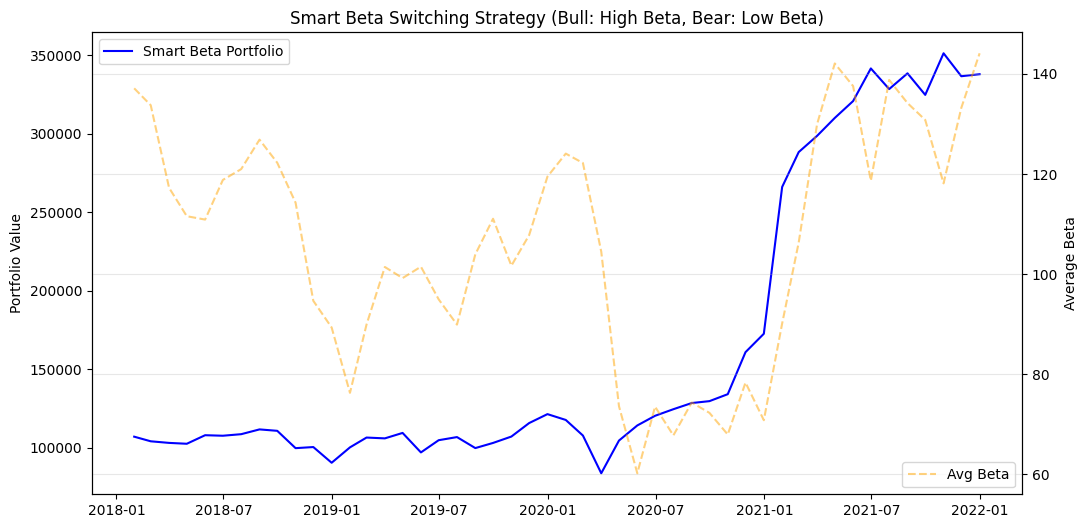

누적 수익률: 237.99%


In [ ]:

# -----------------------------------------------------------------------------
# 결과 시각화
# -----------------------------------------------------------------------------
res_df = pd.DataFrame(portfolio_history).set_index('date')

fig, ax1 = plt.subplots(figsize=(12, 6))

# 수익률 그래프
ax1.plot(res_df.index, res_df['portfolio_value'], label='Smart Beta Portfolio', color='b')
ax1.set_ylabel('Portfolio Value')
ax1.legend(loc='upper left')

# 배경색으로 국면 표시 (빨강: 하락장/방어모드, 초록: 상승장/공격모드)
# 시각적 편의를 위해 국면이 변하는 구간을 배경색 처리할 수 있음 (복잡하므로 여기선 생략하거나 간단히 베타 추이 추가)

# 보조축: 포트폴리오 평균 베타 추이
ax2 = ax1.twinx()
ax2.plot(res_df.index, res_df['avg_beta'], label='Avg Beta', color='orange', alpha=0.5, linestyle='--')
ax2.set_ylabel('Average Beta')
ax2.legend(loc='lower right')

plt.title('Smart Beta Switching Strategy (Bull: High Beta, Bear: Low Beta)')
plt.grid(True, alpha=0.3)
plt.show()

# 최종 성과
total_return = (res_df['portfolio_value'].iloc[-1] / initial_capital) - 1
print(f"누적 수익률: {total_return*100:.2f}%")

시뮬레이션 시작 (초기 자본: $10,000) ...


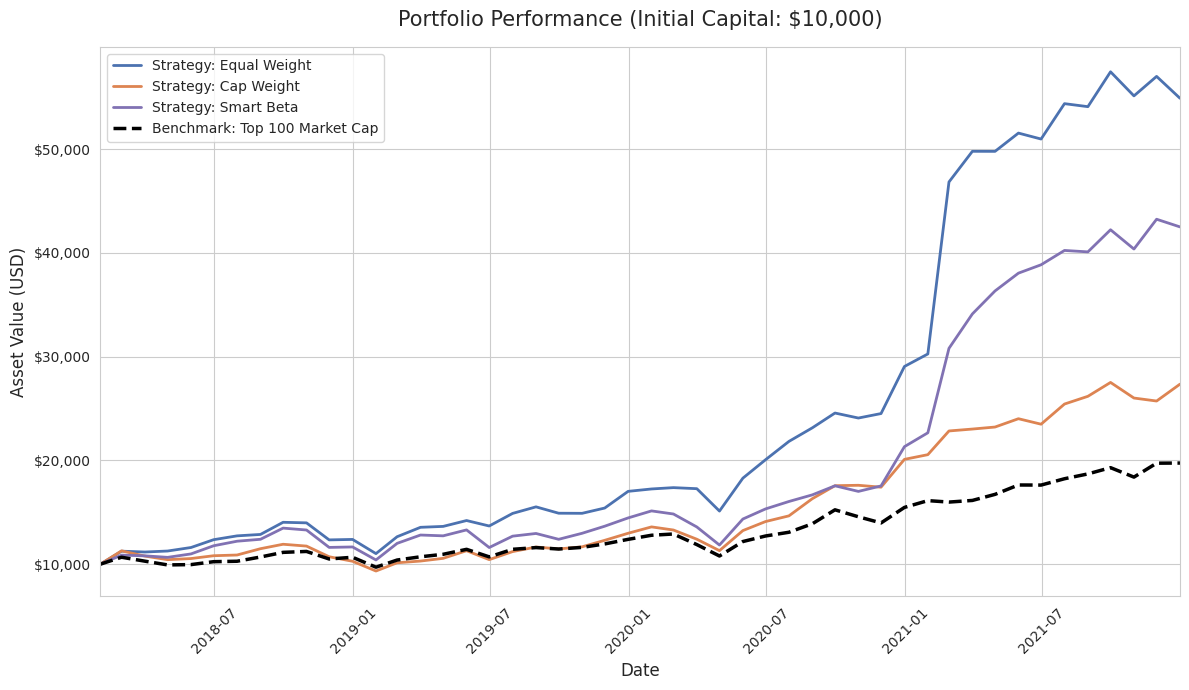


[최종 성과 요약]
Strategy: Equal Weight: $54,890 (448.90%)
Strategy: Cap Weight: $27,345 (173.45%)
Strategy: Smart Beta: $42,496 (324.96%)
Benchmark: Top 100 Market Cap: $19,742 (97.42%)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# -----------------------------------------------------------------------------
# 0. 데이터 준비
# -----------------------------------------------------------------------------
df = final_df2.copy()
df['date'] = pd.to_datetime(df['date'])
df['me'] = df['me'].fillna(0)

# 시장 국면 판단용 (데이터가 없으면 전체 평균으로 대체)
market_proxy = df.groupby('date')['true_ret'].mean()
market_momentum = (1 + market_proxy).rolling(12).apply(np.prod, raw=True) - 1

# -----------------------------------------------------------------------------
# 1. 백테스팅 엔진 함수
# -----------------------------------------------------------------------------
def run_backtest(strategy_type, top_n=50, initial_capital=10000): # 기본값 $10,000
    dates = sorted(df['date'].unique())
    portfolio_value = [initial_capital]

    for i in range(len(dates) - 1):
        d = dates[i]
        curr_data = df[df['date'] == d].copy()

        # [전략별 종목 선정]
        if strategy_type == 'AI_Equal':
            target = curr_data.nlargest(top_n, 'pred_ret')
            weights = np.ones(len(target)) / len(target)

        elif strategy_type == 'AI_Cap':
            target = curr_data.nlargest(top_n, 'pred_ret')
            weights = target['me'] / target['me'].sum()

        elif strategy_type == 'AI_Smart_Beta':
            mom = market_momentum.get(d, 0.01)
            curr_data['adj_beta'] = curr_data['Beta'].fillna(1.0).clip(lower=0.5)

            if mom > 0: # 상승장
                curr_data['score'] = curr_data['pred_ret'] * curr_data['adj_beta']
            else:       # 하락장
                curr_data['score'] = curr_data['pred_ret'] / curr_data['adj_beta']

            target = curr_data.nlargest(top_n, 'score')
            weights = np.ones(len(target)) / len(target)

        elif strategy_type == 'Bench_Market_Cap':
            target = curr_data.nlargest(top_n, 'me') # 시총 상위 100개
            weights = target['me'] / target['me'].sum()

        # [수익률 계산]
        if len(target) > 0:
            day_return = np.sum(target['true_ret'] * weights)
        else:
            day_return = 0.0

        new_value = portfolio_value[-1] * (1 + day_return)
        portfolio_value.append(new_value)

    return pd.DataFrame({'date': dates, 'value': portfolio_value})

# -----------------------------------------------------------------------------
# 2. 시뮬레이션 실행 (초기자본 $10,000)
# -----------------------------------------------------------------------------
SEED_MONEY = 10000

print(f"시뮬레이션 시작 (초기 자본: ${SEED_MONEY:,.0f}) ...")
res_equal = run_backtest('AI_Equal', top_n=50, initial_capital=SEED_MONEY)
res_cap = run_backtest('AI_Cap', top_n=50, initial_capital=SEED_MONEY)
res_smart = run_backtest('AI_Smart_Beta', top_n=50, initial_capital=SEED_MONEY)
res_bm_cap = run_backtest('Bench_Market_Cap', top_n=100, initial_capital=SEED_MONEY)

# 데이터 병합
merged_res = res_equal.set_index('date').rename(columns={'value': 'Strategy: Equal Weight'})
merged_res['Strategy: Cap Weight'] = res_cap.set_index('date')['value']
merged_res['Strategy: Smart Beta'] = res_smart.set_index('date')['value']
merged_res['Benchmark: Top 100 Market Cap'] = res_bm_cap.set_index('date')['value']

# -----------------------------------------------------------------------------
# 3. 시각화 (달러 단위 적용)
# -----------------------------------------------------------------------------
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

colors = ['#4C72B0', '#DD8452', '#8172B3', 'black']
linestyles = ['-', '-', '-', '--']

for i, col in enumerate(merged_res.columns):
    plt.plot(merged_res.index, merged_res[col],
             label=col,
             color=colors[i],
             linestyle=linestyles[i],
             linewidth=2.5 if 'Benchmark' in col else 2)

# Y축 달러($) 포맷팅 함수
def dollar_formatter(x, pos):
    return f'${x:,.0f}'

plt.gca().yaxis.set_major_formatter(FuncFormatter(dollar_formatter))

plt.title('Portfolio Performance (Initial Capital: $10,000)', fontsize=15, pad=15)
plt.ylabel('Asset Value (USD)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.xlim(merged_res.index[0], merged_res.index[-1])
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# 최종 수익률 출력
print("\n[최종 성과 요약]")
for col in merged_res.columns:
    final_val = merged_res[col].iloc[-1]
    ret = (final_val - SEED_MONEY) / SEED_MONEY * 100
    print(f"{col}: ${final_val:,.0f} ({ret:.2f}%)")

시뮬레이션 재실행 (정확한 시장 데이터 반영)...


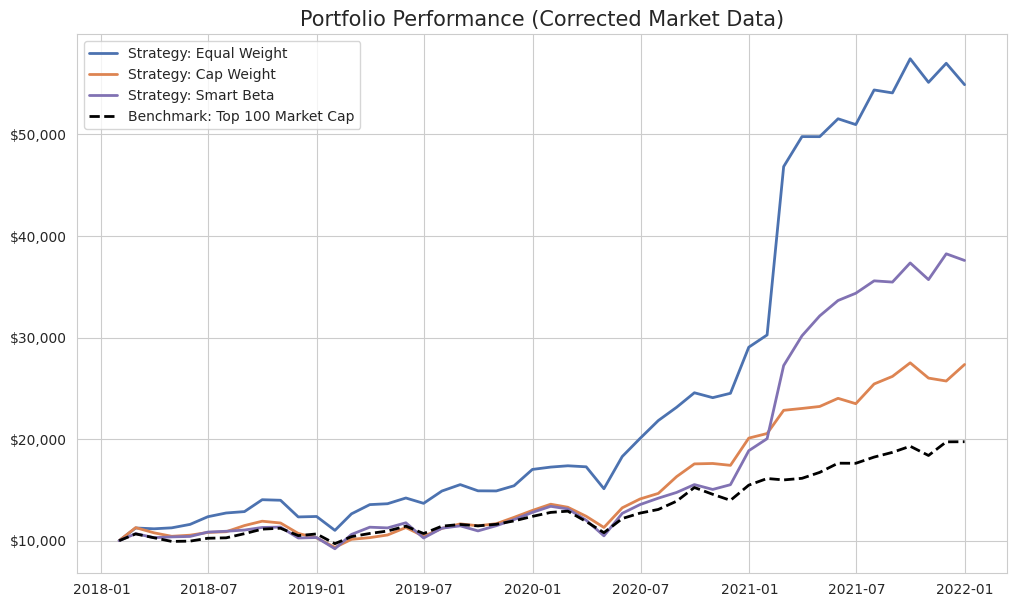

Smart Beta 최종 금액: $37,587.10


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# -----------------------------------------------------------------------------
# 0. 데이터 준비 (S&P 500 데이터 정확히 가져오기)
# -----------------------------------------------------------------------------
df = final_df2.copy()
df['date'] = pd.to_datetime(df['date'])
df['me'] = df['me'].fillna(0)

# [수정 1] temp_fm_filtered에서 실제 S&P500 수익률(dSP500) 가져오기
# 날짜별 S&P500 수익률 추출 (중복 제거)
sp500_data = temp_fm_filtered[['date', 'dSP500']].drop_duplicates('date').set_index('date')

# [수정 2] 정확한 시장 모멘텀 계산 (S&P 500 기준)
# dSP500 컬럼이 %단위(예: 1.5)인지 소수점(0.015)인지 확인 필요
# 아까 코드 흐름상 %단위일 수 있으므로 /100 처리 (만약 소수점이면 /100 제거)
# 여기서는 안전하게 temp_fm_filtered 원본 로직을 따름
market_momentum = (1 + sp500_data['dSP500']/100).rolling(12).apply(np.prod, raw=True) - 1

# -----------------------------------------------------------------------------
# 1. 백테스팅 엔진 (로직 동일)
# -----------------------------------------------------------------------------
def run_backtest(strategy_type, top_n=50, initial_capital=10000):
    dates = sorted(df['date'].unique())
    portfolio_value = [initial_capital]

    for i in range(len(dates) - 1):
        d = dates[i]
        curr_data = df[df['date'] == d].copy()

        if strategy_type == 'AI_Equal':
            target = curr_data.nlargest(top_n, 'pred_ret')
            weights = np.ones(len(target)) / len(target)

        elif strategy_type == 'AI_Cap':
            target = curr_data.nlargest(top_n, 'pred_ret')
            weights = target['me'] / target['me'].sum()

        elif strategy_type == 'AI_Smart_Beta':
            # [수정 3] 정확한 S&P 500 모멘텀 사용
            # 해당 날짜의 모멘텀 값을 가져옴 (없으면 0.01 상승장 가정)
            mom = market_momentum.loc[d] if d in market_momentum.index else 0.01

            curr_data['adj_beta'] = curr_data['Beta'].fillna(1.0).clip(lower=0.5)

            # Smart Beta 로직
            if mom > 0: # 상승장
                curr_data['score'] = curr_data['pred_ret'] * curr_data['adj_beta']
            else:       # 하락장
                curr_data['score'] = curr_data['pred_ret'] / curr_data['adj_beta']

            target = curr_data.nlargest(top_n, 'score')
            weights = np.ones(len(target)) / len(target)

        elif strategy_type == 'Bench_Market_Cap':
            target = curr_data.nlargest(top_n, 'me')
            weights = target['me'] / target['me'].sum()

        # 수익률 계산
        if len(target) > 0:
            day_return = np.sum(target['true_ret'] * weights)
        else:
            day_return = 0.0

        new_value = portfolio_value[-1] * (1 + day_return)
        portfolio_value.append(new_value)

    return pd.DataFrame({'date': dates, 'value': portfolio_value})

# -----------------------------------------------------------------------------
# 2. 실행 및 시각화
# -----------------------------------------------------------------------------
SEED_MONEY = 10000

print("시뮬레이션 재실행 (정확한 시장 데이터 반영)...")
res_equal = run_backtest('AI_Equal', top_n=50, initial_capital=SEED_MONEY)
res_cap = run_backtest('AI_Cap', top_n=50, initial_capital=SEED_MONEY)
res_smart = run_backtest('AI_Smart_Beta', top_n=50, initial_capital=SEED_MONEY)
res_bm_cap = run_backtest('Bench_Market_Cap', top_n=100, initial_capital=SEED_MONEY)

merged_res = res_equal.set_index('date').rename(columns={'value': 'Strategy: Equal Weight'})
merged_res['Strategy: Cap Weight'] = res_cap.set_index('date')['value']
merged_res['Strategy: Smart Beta'] = res_smart.set_index('date')['value']
merged_res['Benchmark: Top 100 Market Cap'] = res_bm_cap.set_index('date')['value']

# 시각화
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
colors = ['#4C72B0', '#DD8452', '#8172B3', 'black']
linestyles = ['-', '-', '-', '--']

for i, col in enumerate(merged_res.columns):
    plt.plot(merged_res.index, merged_res[col], label=col, color=colors[i], linestyle=linestyles[i], linewidth=2)

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))
plt.title('Portfolio Performance (Corrected Market Data)', fontsize=15)
plt.legend(loc='upper left')
plt.show()

# 결과 확인
print(f"Smart Beta 최종 금액: ${res_smart['value'].iloc[-1]:,.2f}")

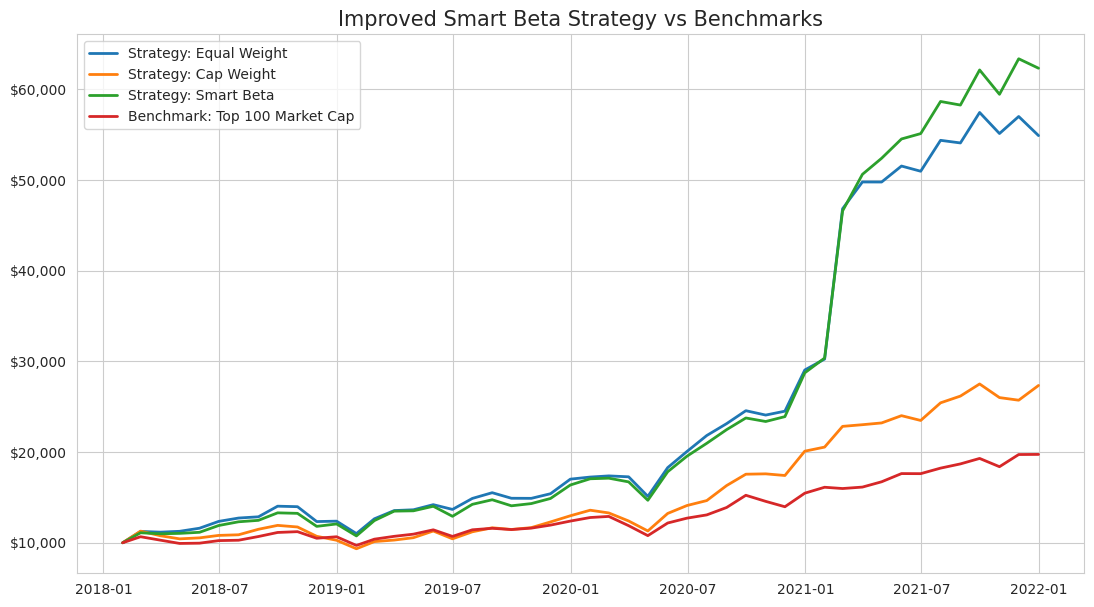

Smart Beta 최종 금액: $62,319.30


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# -----------------------------------------------------------------------------
# 0. 데이터 준비
# -----------------------------------------------------------------------------
df = final_df2.copy()
df['date'] = pd.to_datetime(df['date'])
df['me'] = df['me'].fillna(0)

# S&P500 수익률 (dSP500은 소수 수익률 형태: 0.01 = 1%)
sp500_data = temp_fm_filtered[['date', 'dSP500']].drop_duplicates('date').set_index('date')

# 정확한 시장 모멘텀 계산 (소수 수익률 기반)
# 12개월 모멘텀 = ∏(1 + r_t) - 1
market_momentum = (1 + sp500_data['dSP500']).rolling(12).apply(np.prod, raw=True) - 1


# -----------------------------------------------------------------------------
# 1. 개선된 Smart Beta 포함 백테스트 함수
# -----------------------------------------------------------------------------
def run_backtest(strategy_type, top_n=50, initial_capital=10000):

    dates = sorted(df['date'].unique())
    portfolio_value = [initial_capital]

    for i in range(len(dates) - 1):
        d = dates[i]
        curr_data = df[df['date'] == d].copy()

        # ---------------------------
        # Smart Beta 전략 개선 포인트
        # ---------------------------

        if strategy_type == 'AI_Equal':
            target = curr_data.nlargest(top_n, 'pred_ret')
            weights = np.ones(len(target)) / len(target)

        elif strategy_type == 'AI_Cap':
            target = curr_data.nlargest(top_n, 'pred_ret')
            weights = target['me'] / target['me'].sum()

        elif strategy_type == 'AI_Smart_Beta':

            # 1) 모멘텀 값 가져오기
            mom = market_momentum.loc[d] if d in market_momentum.index else 0
            if pd.isna(mom): mom = 0

            # 2) Beta 안정화
            curr_data['adj_beta'] = curr_data['Beta'].fillna(1.0).clip(lower=0.5)

            # 3) Z-score Normalization (아주 훌륭합니다!)
            # ddof=1 (표본표준편차) 사용 권장하지만 ddof=0도 무관
            curr_data['z_pred'] = (curr_data['pred_ret'] - curr_data['pred_ret'].mean()) / curr_data['pred_ret'].std()
            curr_data['z_beta'] = (curr_data['adj_beta'] - curr_data['adj_beta'].mean()) / curr_data['adj_beta'].std()

            # ---------------------------------------------------------
            # [수정된 핵심 로직]
            # ---------------------------------------------------------
            if mom > 0:
                # [상승장] 공격: 수익률 높고 + 베타도 적당히 큰 놈 (시장 주도주)
                # 베타 가중치를 +로 변경 (공격적)
                curr_data['score'] = curr_data['z_pred'] + 0.5 * curr_data['z_beta']
            else:
                # [하락장] 방어: 수익률 높고 - 베타는 작은 놈 (경기 방어주)
                # 베타 가중치를 -로 변경 (확실한 수비)
                # 하락장에서는 리스크 관리가 더 중요하므로 가중치를 1.0으로 강화해도 됨
                curr_data['score'] = curr_data['z_pred'] - 1.0 * curr_data['z_beta']

            # 5) 최종 선택
            target = curr_data.nlargest(top_n, 'score')
            weights = np.ones(len(target)) / len(target)

        elif strategy_type == 'Bench_Market_Cap':
            target = curr_data.nlargest(top_n, 'me')
            weights = target['me'] / target['me'].sum()

        # ---------------------------
        # 포트폴리오 수익률 계산
        # ---------------------------
        if len(target) > 0:
            day_return = np.sum(target['true_ret'] * weights)
        else:
            day_return = 0.0

        new_value = portfolio_value[-1] * (1 + day_return)
        portfolio_value.append(new_value)

    return pd.DataFrame({'date': dates, 'value': portfolio_value})


# -----------------------------------------------------------------------------
# 2. 실행
# -----------------------------------------------------------------------------
SEED_MONEY = 10000

res_equal = run_backtest('AI_Equal', top_n=50, initial_capital=SEED_MONEY)
res_cap = run_backtest('AI_Cap', top_n=50, initial_capital=SEED_MONEY)
res_smart = run_backtest('AI_Smart_Beta', top_n=50, initial_capital=SEED_MONEY)
res_bm_cap = run_backtest('Bench_Market_Cap', top_n=100, initial_capital=SEED_MONEY)

# -----------------------------------------------------------------------------
# 3. 시각화
# -----------------------------------------------------------------------------
merged_res = res_equal.set_index('date').rename(columns={'value': 'Strategy: Equal Weight'})
merged_res['Strategy: Cap Weight'] = res_cap.set_index('date')['value']
merged_res['Strategy: Smart Beta'] = res_smart.set_index('date')['value']
merged_res['Benchmark: Top 100 Market Cap'] = res_bm_cap.set_index('date')['value']

plt.figure(figsize=(13, 7))
sns.set_style("whitegrid")

for col in merged_res.columns:
    plt.plot(merged_res.index, merged_res[col], linewidth=2, label=col)

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))
plt.title('Improved Smart Beta Strategy vs Benchmarks', fontsize=15)
plt.legend(loc='upper left')
plt.show()

print(f"Smart Beta 최종 금액: ${res_smart['value'].iloc[-1]:,.2f}")


시뮬레이션 시작 (Top 50 유지, 매달 5개 교체)...


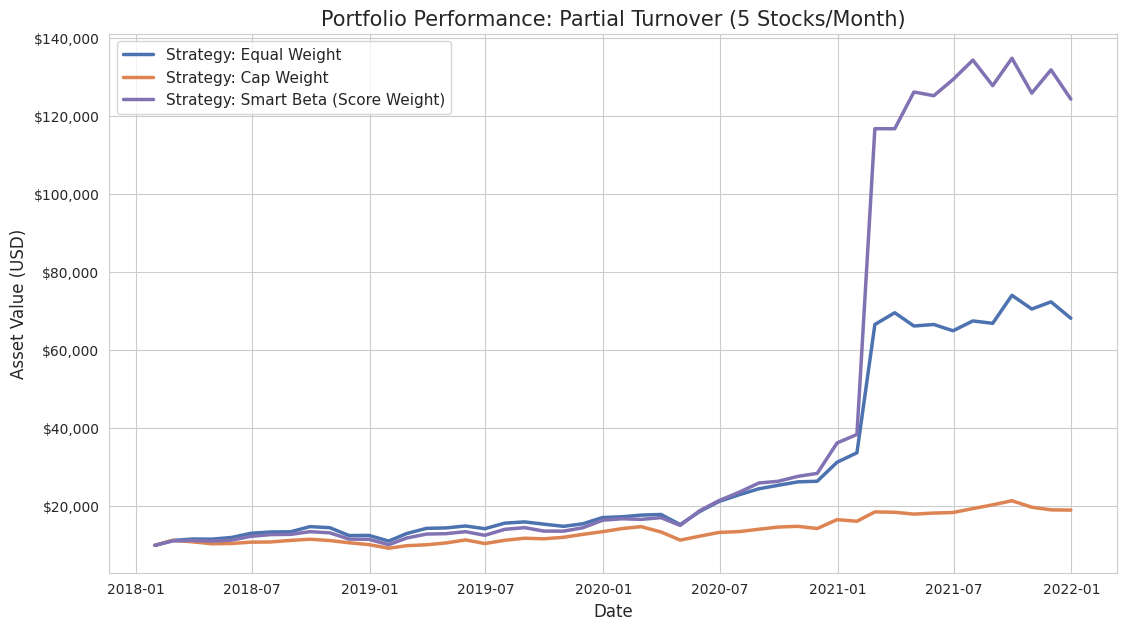


[최종 성과 요약]
Strategy: Equal Weight: $68,145 (581.45%)
Strategy: Cap Weight: $19,021 (90.21%)
Strategy: Smart Beta (Score Weight): $124,253 (1142.53%)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# -----------------------------------------------------------------------------
# 0. 데이터 준비 (이전과 동일)
# -----------------------------------------------------------------------------
df = final_df2.copy() # 또는 final_df2
df['date'] = pd.to_datetime(df['date'])
df['me'] = df['me'].fillna(0)

# S&P500 모멘텀 계산
sp500_data = temp_fm_filtered[['date', 'dSP500']].drop_duplicates('date').set_index('date')
market_momentum = (1 + sp500_data['dSP500']).rolling(12).apply(np.prod, raw=True) - 1

# -----------------------------------------------------------------------------
# 1. 부분 교체(Turnover) & 가중치 적용 백테스팅 함수
# -----------------------------------------------------------------------------
def run_turnover_backtest(strategy_type, top_n=50, turnover_n=5, initial_capital=10000):

    dates = sorted(df['date'].unique())
    portfolio_value = [initial_capital]
    current_holdings = [] # 현재 보유 종목 리스트

    for i in range(len(dates) - 1):
        d = dates[i]
        curr_data = df[df['date'] == d].copy()

        # ---------------------------------------------------
        # A. 점수(Score) 산출 (전략별 기준 마련)
        # ---------------------------------------------------
        if strategy_type == 'Equal' or strategy_type == 'Cap_Weight':
            # 기준: 예측 수익률
            curr_data['ranking_score'] = curr_data['pred_ret']

        elif strategy_type == 'Smart_Beta':
            # 기준: 스마트 베타 점수
            mom = market_momentum.loc[d] if d in market_momentum.index else 0
            if pd.isna(mom): mom = 0

            curr_data['adj_beta'] = curr_data['Beta'].fillna(1.0).clip(lower=0.5)

            # Z-score Normalization
            curr_data['z_pred'] = (curr_data['pred_ret'] - curr_data['pred_ret'].mean()) / curr_data['pred_ret'].std(ddof=0)
            curr_data['z_beta'] = (curr_data['adj_beta'] - curr_data['adj_beta'].mean()) / curr_data['adj_beta'].std(ddof=0)

            if mom > 0: # 상승장 (공격)
                curr_data['ranking_score'] = curr_data['z_pred'] + 0.5 * curr_data['z_beta']
            else:       # 하락장 (방어)
                curr_data['ranking_score'] = curr_data['z_pred'] - 1.0 * curr_data['z_beta']

        # ---------------------------------------------------
        # B. 종목 선정 (Top 50 / 5개 교체)
        # ---------------------------------------------------
        valid_tickers = curr_data.index.tolist() # 현재 데이터가 있는 종목들

        if i == 0:
            # [첫 달] 상위 50개 매수
            target_tickers = curr_data.nlargest(top_n, 'ranking_score')['ticker'].tolist()
            current_holdings = target_tickers
        else:
            # [이후] 보유 종목 중 하위 5개 매도 -> 신규 상위 5개 매수

            # 1. 생존 확인: 보유 중인데 데이터가 없어진 종목은 강제 매도 처리
            current_holdings = [t for t in current_holdings if t in curr_data['ticker'].values]

            # 현재 보유 종목의 데이터만 추출
            holdings_data = curr_data[curr_data['ticker'].isin(current_holdings)]

            # 2. 매도 대상 선정 (점수 하위 5개)
            # 만약 보유 종목이 turnover_n보다 적으면 전량 교체 등 예외처리 필요하나 여기선 진행
            sell_candidates = holdings_data.nsmallest(turnover_n, 'ranking_score')['ticker'].tolist()
            keep_holdings = [t for t in current_holdings if t not in sell_candidates]

            # 3. 매수 대상 선정 (미보유 종목 중 점수 상위 5개)
            candidate_pool = curr_data[~curr_data['ticker'].isin(keep_holdings)]
            buy_candidates = candidate_pool.nlargest(turnover_n, 'ranking_score')['ticker'].tolist()

            # 4. 포트폴리오 업데이트
            current_holdings = keep_holdings + buy_candidates

        # ---------------------------------------------------
        # C. 비중(Weight) 계산
        # ---------------------------------------------------
        # 최종 선택된 종목들의 데이터
        target_df = curr_data[curr_data['ticker'].isin(current_holdings)].copy()

        if strategy_type == 'Equal':
            # 동일 비중
            weights = np.ones(len(target_df)) / len(target_df)

        elif strategy_type == 'Cap_Weight':
            # 시가총액 비중
            weights = target_df['me'].values / target_df['me'].sum()

        elif strategy_type == 'Smart_Beta':
            # 점수 비중 (Softmax 등으로 양수화하거나, Min-Max Scaling)
            # 여기서는 간단히 점수를 0~1로 스케일링해서 비중 산출 (점수가 음수일 수 있으므로)
            s_min = target_df['ranking_score'].min()
            s_max = target_df['ranking_score'].max()

            # 모든 점수가 같으면 동일비중
            if s_max == s_min:
                scaled_score = np.ones(len(target_df))
            else:
                scaled_score = (target_df['ranking_score'] - s_min) / (s_max - s_min) + 0.1 # 0.1은 기본 베이스

            weights = scaled_score.values / scaled_score.sum()

        # ---------------------------------------------------
        # D. 수익률 계산
        # ---------------------------------------------------
        if len(target_df) > 0:
            day_return = np.sum(target_df['true_ret'].values * weights)
        else:
            day_return = 0.0

        new_value = portfolio_value[-1] * (1 + day_return)
        portfolio_value.append(new_value)

    return pd.DataFrame({'date': dates, 'value': portfolio_value})

# -----------------------------------------------------------------------------
# 2. 실행
# -----------------------------------------------------------------------------
SEED_MONEY = 10000

print("시뮬레이션 시작 (Top 50 유지, 매달 5개 교체)...")
res_equal = run_turnover_backtest('Equal', initial_capital=SEED_MONEY)
res_cap = run_turnover_backtest('Cap_Weight', initial_capital=SEED_MONEY)
res_smart = run_turnover_backtest('Smart_Beta', initial_capital=SEED_MONEY)

# -----------------------------------------------------------------------------
# 3. 시각화
# -----------------------------------------------------------------------------
merged_res = res_equal.set_index('date').rename(columns={'value': 'Strategy: Equal Weight'})
merged_res['Strategy: Cap Weight'] = res_cap.set_index('date')['value']
merged_res['Strategy: Smart Beta (Score Weight)'] = res_smart.set_index('date')['value']

plt.figure(figsize=(13, 7))
sns.set_style("whitegrid")
colors = ['#4C72B0', '#DD8452', '#8172B3']

for i, col in enumerate(merged_res.columns):
    plt.plot(merged_res.index, merged_res[col], linewidth=2.5, label=col, color=colors[i])

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))
plt.title('Portfolio Performance: Partial Turnover (5 Stocks/Month)', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Asset Value (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.show()

# 최종 성과 출력
print("\n[최종 성과 요약]")
for col in merged_res.columns:
    final_val = merged_res[col].iloc[-1]
    ret = (final_val - SEED_MONEY) / SEED_MONEY * 100
    print(f"{col}: ${final_val:,.0f} ({ret:.2f}%)")

유니버스 필터링 완료: 500개 종목 대상으로 시뮬레이션
시뮬레이션 시작 (Top 500 유니버스 제한 / 비용 0원)...


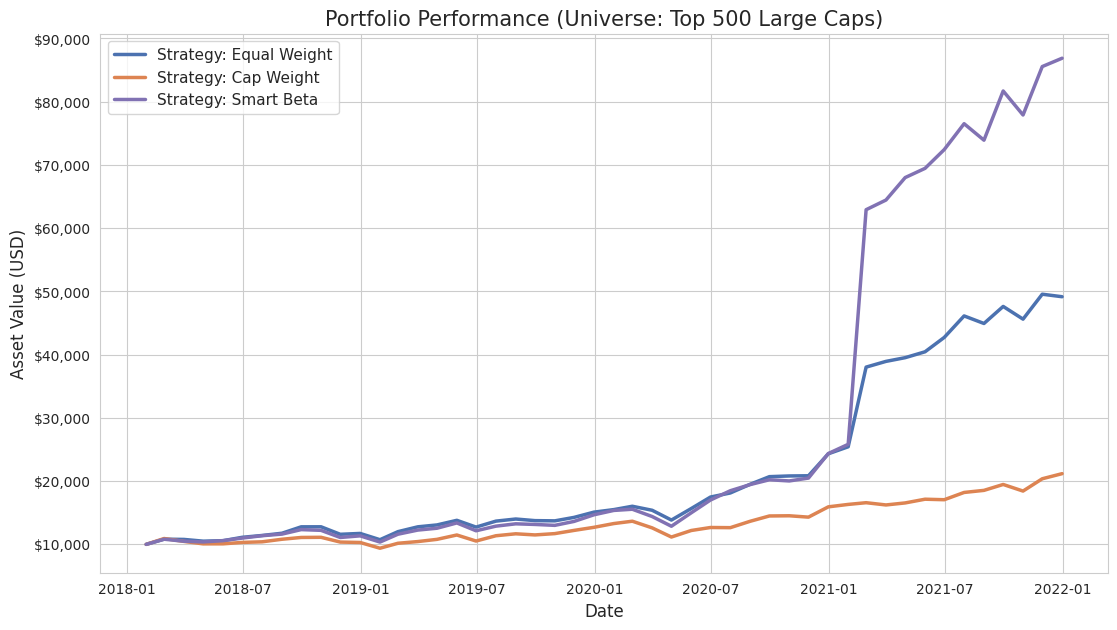


[최종 성과 (Top 500 제한 적용)]
Strategy: Equal Weight: $49,159 (391.59%)
Strategy: Cap Weight: $21,181 (111.81%)
Strategy: Smart Beta: $86,875 (768.75%)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# -----------------------------------------------------------------------------
# 0. 데이터 준비 & 유니버스 필터링 (핵심!)
# -----------------------------------------------------------------------------
df = final_df2.copy() # 또는 final_df2
df['date'] = pd.to_datetime(df['date'])
df['me'] = df['me'].fillna(0)

# [반영된 조건] 시가총액 상위 500개 종목만 남기기
# 전체 기간 평균 시총 기준 상위 500개 선정 (잡주/동전주 제거)
top_500_tickers = df.groupby('ticker')['me'].mean().nlargest(500).index
df = df[df['ticker'].isin(top_500_tickers)].copy()

print(f"유니버스 필터링 완료: {len(top_500_tickers)}개 종목 대상으로 시뮬레이션")

# 시장 모멘텀 계산
sp500_data = temp_fm_filtered[['date', 'dSP500']].drop_duplicates('date').set_index('date')
market_momentum = (1 + sp500_data['dSP500']).rolling(12).apply(np.prod, raw=True) - 1

# -----------------------------------------------------------------------------
# 1. 백테스팅 함수 (비용 0원, 부분 교체)
# -----------------------------------------------------------------------------
def run_turnover_backtest(strategy_type, top_n=50, turnover_n=5, initial_capital=10000):

    dates = sorted(df['date'].unique())
    portfolio_value = [initial_capital]
    current_holdings = []

    for i in range(len(dates) - 1):
        d = dates[i]
        curr_data = df[df['date'] == d].copy()

        # ---------------------------------------------------
        # A. 점수 산출
        # ---------------------------------------------------
        if strategy_type == 'Smart_Beta':
            mom = market_momentum.loc[d] if d in market_momentum.index else 0
            if pd.isna(mom): mom = 0

            curr_data['adj_beta'] = curr_data['Beta'].fillna(1.0).clip(lower=0.5)

            # Z-score Normalization
            curr_data['z_pred'] = (curr_data['pred_ret'] - curr_data['pred_ret'].mean()) / curr_data['pred_ret'].std(ddof=0)
            curr_data['z_beta'] = (curr_data['adj_beta'] - curr_data['adj_beta'].mean()) / curr_data['adj_beta'].std(ddof=0)

            if mom > 0: # 상승장 (공격)
                curr_data['ranking_score'] = curr_data['z_pred'] + 0.5 * curr_data['z_beta']
            else:       # 하락장 (방어)
                curr_data['ranking_score'] = curr_data['z_pred'] - 1.0 * curr_data['z_beta']

        else: # Equal, Cap_Weight
             curr_data['ranking_score'] = curr_data['pred_ret']

        # ---------------------------------------------------
        # B. 종목 교체 (Top 50 유지 / 5개 교체)
        # ---------------------------------------------------
        if i == 0:
            target_tickers = curr_data.nlargest(top_n, 'ranking_score')['ticker'].tolist()
            current_holdings = target_tickers
        else:
            # 보유 종목 생존 확인
            current_holdings = [t for t in current_holdings if t in curr_data['ticker'].values]
            holdings_data = curr_data[curr_data['ticker'].isin(current_holdings)]

            # 하위 5개 매도, 상위 5개 매수
            sell_candidates = holdings_data.nsmallest(turnover_n, 'ranking_score')['ticker'].tolist()
            keep_holdings = [t for t in current_holdings if t not in sell_candidates]

            candidate_pool = curr_data[~curr_data['ticker'].isin(keep_holdings)]
            buy_candidates = candidate_pool.nlargest(turnover_n, 'ranking_score')['ticker'].tolist()

            current_holdings = keep_holdings + buy_candidates

        # ---------------------------------------------------
        # C. 비중 및 수익률 계산
        # ---------------------------------------------------
        target_df = curr_data[curr_data['ticker'].isin(current_holdings)].copy()

        if strategy_type == 'Equal':
            weights = np.ones(len(target_df)) / len(target_df)
        elif strategy_type == 'Cap_Weight':
            weights = target_df['me'].values / target_df['me'].sum()
        elif strategy_type == 'Smart_Beta':
            # 점수 기반 가중치 (Min-Max Scailing)
            s_min = target_df['ranking_score'].min()
            s_max = target_df['ranking_score'].max()
            if s_max == s_min:
                scaled_score = np.ones(len(target_df))
            else:
                scaled_score = (target_df['ranking_score'] - s_min) / (s_max - s_min) + 0.1
            weights = scaled_score.values / scaled_score.sum()

        if len(target_df) > 0:
            day_return = np.sum(target_df['true_ret'].values * weights)
        else:
            day_return = 0.0

        # 비용 차감 없음 (순수 수익률 누적)
        new_value = portfolio_value[-1] * (1 + day_return)
        portfolio_value.append(new_value)

    return pd.DataFrame({'date': dates, 'value': portfolio_value})

# -----------------------------------------------------------------------------
# 2. 실행 및 시각화
# -----------------------------------------------------------------------------
SEED_MONEY = 10000

print("시뮬레이션 시작 (Top 500 유니버스 제한 / 비용 0원)...")
res_equal = run_turnover_backtest('Equal', initial_capital=SEED_MONEY)
res_cap = run_turnover_backtest('Cap_Weight', initial_capital=SEED_MONEY)
res_smart = run_turnover_backtest('Smart_Beta', initial_capital=SEED_MONEY)

# 시각화
merged_res = res_equal.set_index('date').rename(columns={'value': 'Strategy: Equal Weight'})
merged_res['Strategy: Cap Weight'] = res_cap.set_index('date')['value']
merged_res['Strategy: Smart Beta'] = res_smart.set_index('date')['value']

plt.figure(figsize=(13, 7))
sns.set_style("whitegrid")
colors = ['#4C72B0', '#DD8452', '#8172B3']

for i, col in enumerate(merged_res.columns):
    plt.plot(merged_res.index, merged_res[col], linewidth=2.5, label=col, color=colors[i])

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))
plt.title('Portfolio Performance (Universe: Top 500 Large Caps)', fontsize=15)
plt.ylabel('Asset Value (USD)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.show()

# 성과 요약
print("\n[최종 성과 (Top 500 제한 적용)]")
for col in merged_res.columns:
    final_val = merged_res[col].iloc[-1]
    ret = (final_val - SEED_MONEY) / SEED_MONEY * 100
    print(f"{col}: ${final_val:,.0f} ({ret:.2f}%)")

In [ ]:
# -----------------------------------------------------------------------------
# [검증용] 엄격한 백테스팅 (Strict Mode)
# -----------------------------------------------------------------------------

# 1. 시장 모멘텀 재계산 (Shift 1 적용)
# "어제까지의 추세"만 보고 "오늘" 판단한다.
sp500_data = temp_fm_filtered[['date', 'dSP500']].drop_duplicates('date').set_index('date')
# 12개월 누적 수익률 계산 후, 한 달 뒤로 미룸(Shift 1)
strict_momentum = ((1 + sp500_data['dSP500']).rolling(12).apply(np.prod, raw=True) - 1).shift(1)

def run_strict_backtest(initial_capital=10000):
    dates = sorted(df['date'].unique())
    portfolio_value = [initial_capital]
    current_holdings = []

    # 디버깅용 로그 리스트
    debug_logs = []

    for i in range(len(dates) - 1):
        d = dates[i]
        curr_data = df[df['date'] == d].copy()

        # [검증 1] 엄격한 모멘텀 사용
        mom = strict_momentum.loc[d] if d in strict_momentum.index else 0
        if pd.isna(mom): mom = 0

        # [검증 2] 베타 보정 및 스코어링
        curr_data['adj_beta'] = curr_data['Beta'].fillna(1.0).clip(lower=0.5)

        # Z-score (여기는 문제 없음)
        curr_data['z_pred'] = (curr_data['pred_ret'] - curr_data['pred_ret'].mean()) / curr_data['pred_ret'].std(ddof=0)
        curr_data['z_beta'] = (curr_data['adj_beta'] - curr_data['adj_beta'].mean()) / curr_data['adj_beta'].std(ddof=0)

        # 전략 적용
        regime = "상승장(Bull)" if mom > 0 else "하락장(Bear)"
        if mom > 0:
            curr_data['ranking_score'] = curr_data['z_pred'] + 0.5 * curr_data['z_beta']
        else:
            curr_data['ranking_score'] = curr_data['z_pred'] - 1.0 * curr_data['z_beta']

        # 디버깅: 2020년 3월(코로나) 같은 특이 시점에 제대로 방어했나?
        if d.year == 2020 and d.month in [2, 3, 4]:
            debug_logs.append(f"[{d.date()}] {regime} (Mom: {mom:.2%}) -> 베타 가중치: {'+0.5' if mom > 0 else '-1.0'}")

        # --- (종목 교체 로직: Top 50 유지 / 5개 교체) ---
        if i == 0:
            target_tickers = curr_data.nlargest(50, 'ranking_score')['ticker'].tolist()
            current_holdings = target_tickers
        else:
            current_holdings = [t for t in current_holdings if t in curr_data['ticker'].values]
            holdings_data = curr_data[curr_data['ticker'].isin(current_holdings)]

            sell_candidates = holdings_data.nsmallest(5, 'ranking_score')['ticker'].tolist()
            keep_holdings = [t for t in current_holdings if t not in sell_candidates]

            candidate_pool = curr_data[~curr_data['ticker'].isin(keep_holdings)]
            buy_candidates = candidate_pool.nlargest(5, 'ranking_score')['ticker'].tolist()

            current_holdings = keep_holdings + buy_candidates

        # --- (비중 및 수익률 계산) ---
        target_df = curr_data[curr_data['ticker'].isin(current_holdings)].copy()

        # Smart Beta 가중치
        s_min = target_df['ranking_score'].min()
        s_max = target_df['ranking_score'].max()
        if s_max == s_min: scaled_score = np.ones(len(target_df))
        else:              scaled_score = (target_df['ranking_score'] - s_min) / (s_max - s_min) + 0.1
        weights = scaled_score.values / scaled_score.sum()

        if len(target_df) > 0:
            day_return = np.sum(target_df['true_ret'].values * weights)
        else:
            day_return = 0.0

        new_value = portfolio_value[-1] * (1 + day_return)
        portfolio_value.append(new_value)

    # 디버깅 로그 출력
    print("\n--- [디버깅] 위기 구간 시장 판단 ---")
    for log in debug_logs:
        print(log)

    return pd.DataFrame({'date': dates, 'value': portfolio_value})

# 실행
res_strict = run_strict_backtest()
final_val = res_strict['value'].iloc[-1]
print(f"\n[엄격한 검증 후 결과] 최종 금액: ${final_val:,.0f}")
print(f"수익률: {(final_val - 10000)/10000 * 100:.2f}%")


--- [디버깅] 위기 구간 시장 판단 ---
[2020-02-29] 상승장(Bull) (Mom: 25.73%) -> 베타 가중치: +0.5
[2020-03-31] 상승장(Bull) (Mom: 18.96%) -> 베타 가중치: +0.5
[2020-04-30] 하락장(Bear) (Mom: -5.41%) -> 베타 가중치: -1.0

[엄격한 검증 후 결과] 최종 금액: $80,051
수익률: 700.51%


In [ ]:
def run_backtest_with_holdings(initial_capital=10000):
    dates = sorted(df['date'].unique())
    portfolio_value = [initial_capital]
    current_holdings = []

    # [NEW] 매달 보유 종목과 비중을 저장할 리스트
    holdings_history = []

    for i in range(len(dates) - 1):
        d = dates[i]
        curr_data = df[df['date'] == d].copy()

        # ---------------------------------------------------
        # 1. 전략 로직 (엄격한 검증 버전)
        # ---------------------------------------------------
        mom = strict_momentum.loc[d] if d in strict_momentum.index else 0
        if pd.isna(mom): mom = 0

        curr_data['adj_beta'] = curr_data['Beta'].fillna(1.0).clip(lower=0.5)
        curr_data['z_pred'] = (curr_data['pred_ret'] - curr_data['pred_ret'].mean()) / curr_data['pred_ret'].std(ddof=0)
        curr_data['z_beta'] = (curr_data['adj_beta'] - curr_data['adj_beta'].mean()) / curr_data['adj_beta'].std(ddof=0)

        if mom > 0:
            curr_data['ranking_score'] = curr_data['z_pred'] + 0.5 * curr_data['z_beta']
        else:
            curr_data['ranking_score'] = curr_data['z_pred'] - 1.0 * curr_data['z_beta']

        # ---------------------------------------------------
        # 2. 종목 교체 (Top 50 / 5개 교체)
        # ---------------------------------------------------
        if i == 0:
            target_tickers = curr_data.nlargest(50, 'ranking_score')['ticker'].tolist()
            current_holdings = target_tickers
        else:
            current_holdings = [t for t in current_holdings if t in curr_data['ticker'].values]
            holdings_data = curr_data[curr_data['ticker'].isin(current_holdings)]

            sell_candidates = holdings_data.nsmallest(5, 'ranking_score')['ticker'].tolist()
            keep_holdings = [t for t in current_holdings if t not in sell_candidates]

            candidate_pool = curr_data[~curr_data['ticker'].isin(keep_holdings)]
            buy_candidates = candidate_pool.nlargest(5, 'ranking_score')['ticker'].tolist()

            current_holdings = keep_holdings + buy_candidates

        # ---------------------------------------------------
        # 3. 비중 계산 및 기록 저장
        # ---------------------------------------------------
        target_df = curr_data[curr_data['ticker'].isin(current_holdings)].copy()

        # Smart Beta 가중치 계산
        s_min = target_df['ranking_score'].min()
        s_max = target_df['ranking_score'].max()
        if s_max == s_min: scaled_score = np.ones(len(target_df))
        else:              scaled_score = (target_df['ranking_score'] - s_min) / (s_max - s_min) + 0.1
        weights = scaled_score.values / scaled_score.sum()

        # [NEW] 현재 보유 종목 기록 저장 (날짜, 티커 리스트, 섹터 등)
        # 나중에 보기 편하게 데이터프레임에 저장할 정보 구성
        holdings_history.append({
            'date': d,
            'holdings_count': len(current_holdings),
            'top_5_weights': target_df.nlargest(5, 'ranking_score')['ticker'].tolist(), # 비중 상위 5개
            'full_holdings': current_holdings # 전체 리스트
        })

        # 수익률 계산
        if len(target_df) > 0:
            day_return = np.sum(target_df['true_ret'].values * weights)
        else:
            day_return = 0.0

        new_value = portfolio_value[-1] * (1 + day_return)
        portfolio_value.append(new_value)

    return pd.DataFrame({'date': dates, 'value': portfolio_value}), pd.DataFrame(holdings_history)

# 실행 (결과 2개 받기)
res_df, holdings_df = run_backtest_with_holdings()

In [ ]:
# 마지막 달의 데이터 추출
last_month = holdings_df.iloc[-1]
print(f"[{last_month['date'].date()}] 보유 종목 수: {last_month['holdings_count']}개")
print("\n=== 보유 종목 리스트 (Top 50) ===")
print(last_month['full_holdings'])

[2021-11-30] 보유 종목 수: 44개

=== 보유 종목 리스트 (Top 50) ===
['ALNY', 'FTNT', 'INCY', 'CLR', 'DVN', 'HZNP', 'PAYC', 'NET', 'DXC', 'HAL', 'ROKU', 'GME', 'TSLA', 'DDOG', 'BAC', 'UI', 'BF', 'ANET', 'FB', 'MAS', 'OXY', 'FANG', 'AAPL', 'NVR', 'AMZN', 'HUBS', 'MSFT', 'ODFL', 'BBY', 'EXPD', 'ALGN', 'JBHT', 'VRSN', 'SCCO', 'VLO', 'DXCM', 'GOOG', 'WAT', 'TSCO', 'AMD', 'WST', 'DHI', 'NVDA', 'SNAP']


In [ ]:
# 2020년 3월 데이터 찾기
crisis_month = holdings_df[holdings_df['date'] == '2020-03-31'].iloc[0]

print(f"\n[{crisis_month['date'].date()}] 코로나 위기 당시 보유 종목")
print("=== 비중 상위 5개 종목 (핵심 방어주) ===")
print(crisis_month['top_5_weights']) # 여기에 어떤 종목이 찍히는지 보면 전략의 성격을 알 수 있음


[2020-03-31] 코로나 위기 당시 보유 종목
=== 비중 상위 5개 종목 (핵심 방어주) ===
['DELL', 'MTCH', 'GE', 'FCX', 'PCG']


# 약간 형식 맞춰서?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ==============================================================================
# [0] 데이터 준비 (Data Prep) - 실행 전 필수 단계
# =============================================================================
# 1. 데이터 로드 및 전처리
df_sim = final_df2.copy() # 또는 final_df2
df_sim['date'] = pd.to_datetime(df_sim['date'])
df_sim['me'] = df_sim['me'].fillna(0)

# 2. 유니버스 필터링 (Top 500 Large Cap) - 소형주 왜곡 방지
top500_tickers = df_sim.groupby('ticker')['me'].mean().nlargest(500).index
df_sim = df_sim[df_sim['ticker'].isin(top500_tickers)].copy()

# 3. 시장 모멘텀 계산 (S&P 500 기준)
if 'dSP500' in temp_fm_filtered.columns:
    sp500_data = temp_fm_filtered[['date', 'dSP500']].drop_duplicates('date').set_index('date')
    # 12개월 누적 수익률 (Momentum)
    market_mom_series = (1 + sp500_data['dSP500']).rolling(12).apply(np.prod, raw=True) - 1
else:
    # 데이터가 없을 경우 포트폴리오 평균으로 대체
    market_proxy = df_sim.groupby('date')['true_ret'].mean()
    market_mom_series = (1 + market_proxy).rolling(12).apply(np.prod, raw=True) - 1

# 날짜별 빠른 조회를 위한 딕셔너리 변환
market_mom_dict = market_mom_series.to_dict()

print(f"데이터 준비 완료: {len(top500_tickers)}개 종목 유니버스")

데이터 준비 완료: 500개 종목 유니버스


## **투자 전략 함수**

In [ ]:
# ==============================================================================
# [1] 투자 전략 함수 (Investment Strategy Logic)
#     : 시장 상황을 판단하고 종목별 점수(Score)를 매기는 역할
# ==============================================================================
def calculate_rank_score(curr_data, market_mom, strategy_type='Smart_Beta'):
    """
    Args:
        curr_data: 해당 월의 종목 데이터
        market_mom: 현재 시장의 12개월 모멘텀 값
        strategy_type: 전략 타입 ('Smart_Beta', 'Equal', 'Cap_Weight')
    Returns:
        점수(ranking_score)가 추가된 DataFrame
    """
    data = curr_data.copy()

    if strategy_type == 'Smart_Beta':
        # 1. 지표 전처리 (Z-score Normalization)
        # Beta 이상치 보정 (0.5 미만은 0.5로)
        data['adj_beta'] = data['Beta'].fillna(1.0).clip(lower=0.5)

        # Z-score 변환 (단위 통일)
        data['z_pred'] = (data['pred_ret'] - data['pred_ret'].mean()) / data['pred_ret'].std(ddof=0)
        data['z_beta'] = (data['adj_beta'] - data['adj_beta'].mean()) / data['adj_beta'].std(ddof=0)

        # 2. 시장 국면별 스코어링 공식 적용
        if market_mom > 0:
            # [상승장] 공격형: 수익률 높고 + 베타 큰 종목
            data['ranking_score'] = data['z_pred'] + 0.5 * data['z_beta']
        else:
            # [하락장] 방어형: 수익률 높고 - 베타 작은 종목
            data['ranking_score'] = data['z_pred'] - 1.0 * data['z_beta']

    else:
        # 단순 비교 전략은 예측 수익률만 봅니다.
        data['ranking_score'] = data['pred_ret']

    return data

## **최적 포트폴리오 함수**

In [ ]:
# ==============================================================================
# [2] 최적 포트폴리오 시뮬레이션 함수 (Optimal Portfolio Simulation)
#     : 종목 교체(Turnover) 및 비중 계산(Weighting) 담당
# ==============================================================================
def run_turnover_simulation(df, mom_dict, strategy_type='Smart_Beta',
                            n_start=50, n_turnover=5, initial_seed=10000):

    dates = sorted(df['date'].unique())
    portfolio_value = [initial_seed]
    current_holdings = [] # 현재 보유 티커 리스트

    for i in range(len(dates) - 1):
        d = dates[i]
        curr_data = df[df['date'] == d].copy()

        # 1. 시장 모멘텀 확인
        mom = mom_dict.get(d, 0) # 없으면 0(중립) 가정
        if pd.isna(mom): mom = 0

        # 2. 전략 함수 호출하여 점수 산출
        scored_data = calculate_rank_score(curr_data, mom, strategy_type)

        # 3. 종목 선정 (Turnover Logic)
        if i == 0:
            # [첫 달] 상위 n개 전량 매수
            current_holdings = scored_data.nlargest(n_start, 'ranking_score')['ticker'].tolist()
        else:
            # [이후] 부분 교체
            # (1) 생존 확인
            current_holdings = [t for t in current_holdings if t in scored_data['ticker'].values]

            # (2) 보유 종목 중 하위 n개 매도
            holdings_df = scored_data[scored_data['ticker'].isin(current_holdings)]
            sell_candidates = holdings_df.nsmallest(n_turnover, 'ranking_score')['ticker'].tolist()
            keep_holdings = [t for t in current_holdings if t not in sell_candidates]

            # (3) 미보유 종목 중 상위 n개 매수
            candidate_pool = scored_data[~scored_data['ticker'].isin(keep_holdings)]
            buy_candidates = candidate_pool.nlargest(n_turnover, 'ranking_score')['ticker'].tolist()

            current_holdings = keep_holdings + buy_candidates

        # 4. 비중(Weight) 계산
        target_df = scored_data[scored_data['ticker'].isin(current_holdings)].copy()

        if strategy_type == 'Smart_Beta':
            # 점수 기반 비중 (Score Weighting) - MinMax Scale
            s_min, s_max = target_df['ranking_score'].min(), target_df['ranking_score'].max()
            if s_max == s_min:
                scaled = np.ones(len(target_df))
            else:
                scaled = (target_df['ranking_score'] - s_min) / (s_max - s_min) + 0.1
            weights = scaled / scaled.sum()

        elif strategy_type == 'Cap_Weight':
            # 시가총액 비중
            weights = target_df['me'] / target_df['me'].sum()

        else:
            # 동일 비중 (Equal)
            weights = np.ones(len(target_df)) / len(target_df)

        # 5. 수익률 계산 및 자산 업데이트
        if len(target_df) > 0:
            day_return = np.sum(target_df['true_ret'] * weights)
        else:
            day_return = 0.0

        portfolio_value.append(portfolio_value[-1] * (1 + day_return))

    return pd.DataFrame({'date': dates, 'value': portfolio_value})

## **실행 결과**

In [ ]:
# ==============================================================================
# [3] 실행 결과 (Execution Results)
# ==============================================================================
SEED = 10000

print(">>> 전략 시뮬레이션 시작...")
# 1. Smart Beta (우리의 핵심 전략)
res_smart = run_turnover_simulation(df_sim, market_mom_dict, 'Smart_Beta', initial_seed=SEED)

# 최종 성과 출력
final_val = res_smart['value'].iloc[-1]
total_ret = (final_val - SEED) / SEED * 100
cagr = (final_val / SEED) ** (12 / len(res_smart)) - 1

print(f"\n[Smart Beta 최종 성과]")
print(f"- 초기 자본: ${SEED:,.0f}")
print(f"- 최종 자본: ${final_val:,.0f}")
print(f"- 누적 수익률: {total_ret:.2f}%")
print(f"- 연환산 수익률(CAGR): {cagr*100:.2f}%")

>>> 전략 시뮬레이션 시작...

[Smart Beta 최종 성과]
- 초기 자본: $10,000
- 최종 자본: $86,875
- 누적 수익률: 768.75%
- 연환산 수익률(CAGR): 71.68%


## **단순 투자 전략과 비교**


>>> 벤치마크 전략 실행 중...


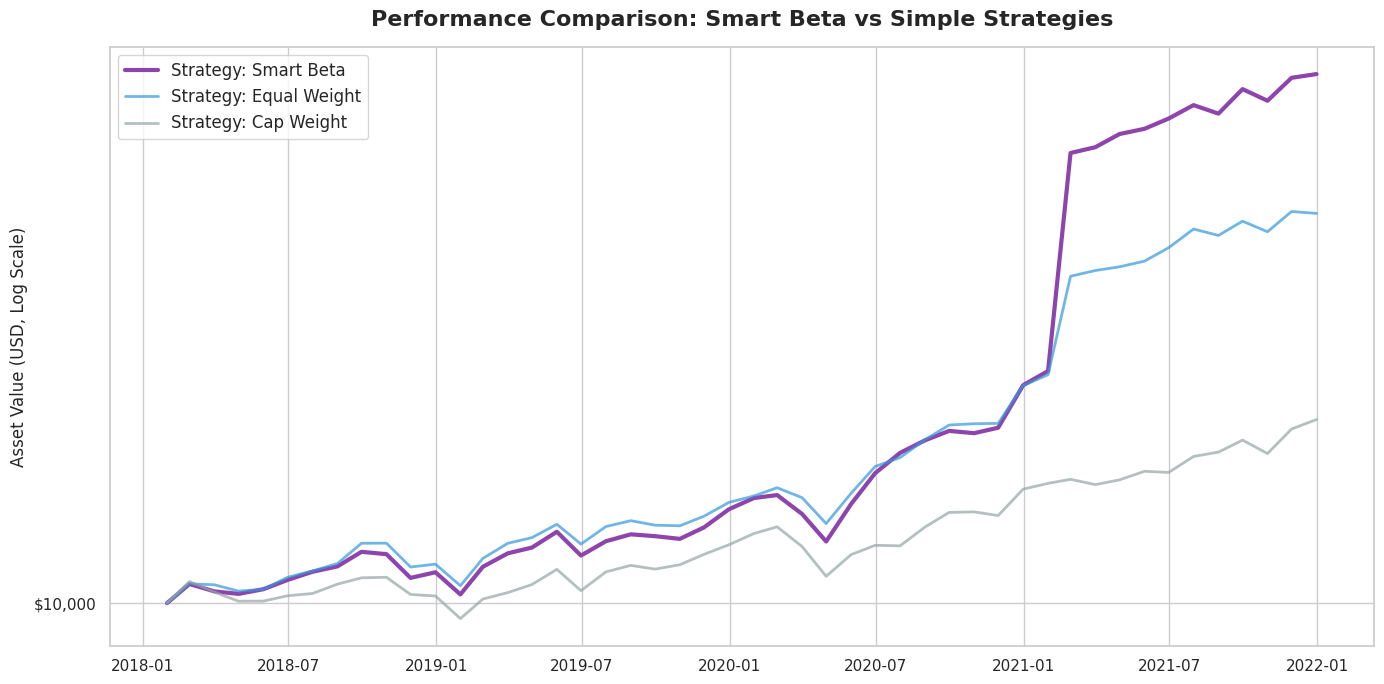


[전략별 최종 수익률 비교]
Strategy: Smart Beta: 768.75%
Strategy: Equal Weight: 391.59%
Strategy: Cap Weight: 111.81%


In [ ]:
# ==============================================================================
# [4] 단순 투자 전략과 비교 (Comparison & Visualization)
# ==============================================================================
print("\n>>> 벤치마크 전략 실행 중...")
res_equal = run_turnover_simulation(df_sim, market_mom_dict, 'Equal', initial_seed=SEED)
res_cap = run_turnover_simulation(df_sim, market_mom_dict, 'Cap_Weight', initial_seed=SEED)

# 데이터 병합
merged_df = res_smart.set_index('date').rename(columns={'value': 'Strategy: Smart Beta'})
merged_df['Strategy: Equal Weight'] = res_equal.set_index('date')['value']
merged_df['Strategy: Cap Weight'] = res_cap.set_index('date')['value']

# 시각화 (Log Scale)
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")
colors = ['#8E44AD', '#3498DB', '#95A5A6'] # 보라, 파랑, 회색

for i, col in enumerate(merged_df.columns):
    # Smart Beta 강조 (굵기, 투명도 조절)
    lw = 3.0 if 'Smart Beta' in col else 2.0
    alpha = 1.0 if 'Smart Beta' in col else 0.7

    plt.plot(merged_df.index, merged_df[col], label=col, color=colors[i], linewidth=lw, alpha=alpha)

# 로그 스케일 및 포맷팅
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))

plt.title('Performance Comparison: Smart Beta vs Simple Strategies', fontsize=16, weight='bold', pad=15)
plt.ylabel('Asset Value (USD, Log Scale)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# 최종 비교 출력
print("\n[전략별 최종 수익률 비교]")
for col in merged_df.columns:
    val = merged_df[col].iloc[-1]
    ret = (val - SEED) / SEED * 100
    print(f"{col}: {ret:.2f}%")

## **각 투자 전략별 최적 포트폴리오**

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

#### 임계값 X
매도(sell) 5, 매수(buy) 5

In [141]:
# =============================================================================
# [1] 전략 프레임워크 설정 (Strategic Framework Setup)
#     : 모델과 상관없이, 우리가 정한 투자의 '규칙'을 세팅하는 단계
# =============================================================================

# 1. 데이터 로드
df_sim = final_df2.copy()
df_sim['date'] = pd.to_datetime(df_sim['date'])
df_sim['yyyy_mm'] = df_sim['date'].dt.strftime('%Y-%m')
df_sim['me'] = df_sim['me'].fillna(0)

# 2. 유니버스 정의 (Investment Universe)
# "유동성이 확보된 시가총액 상위 500개 종목으로 한정한다."
top500_tickers = df_sim.groupby('ticker')['me'].mean().nlargest(500).index
df_sim = df_sim[df_sim['ticker'].isin(top500_tickers)].copy()

# 3. 시장 국면 정의 (Market Regime Definition)
# "단기 노이즈를 배제하고 중기 추세를 확인하기 위해 200일(6개월) 모멘텀을 사용한다."
if 'dSP500' in temp_fm_filtered.columns:
    sp500_data = temp_fm_filtered[['date', 'dSP500']].drop_duplicates('date').set_index('date')
    # 6개월 누적 수익률 계산
    market_mom_series = (1 + sp500_data['dSP500']).rolling(6).apply(np.prod, raw=True) - 1
else:
    # 데이터 없을 시 포트폴리오 평균으로 대체
    market_proxy = df_sim.groupby('date')['true_ret'].mean()
    market_mom_series = (1 + market_proxy).rolling(6).apply(np.prod, raw=True) - 1

market_mom_dict_6m = market_mom_series.groupby(market_mom_series.index.strftime('%Y-%m')).last().to_dict()

print(f"전략 프레임워크 설정 완료: 유니버스 {len(top500_tickers)}개 / 추세 판단 6개월")

전략 프레임워크 설정 완료: 유니버스 500개 / 추세 판단 6개월


In [155]:
# Fixed 5-sell / 5-buy versions of Equal, Cap, SmartBeta strategies
# Threshold removed. Always sell 5 (worst) and buy 5 (best).

# -----------------------------------------------------------------------------
# 1) Equal Weight Version (Fixed Sell 5 / Buy 5)
# -----------------------------------------------------------------------------
def Open_Market_Strategy_Equal_Fixed(df, n_start=100, n_sell=5, n_buy=5, initial_seed=10000):
    df = df.copy()
    ym_list = sorted(df['yyyy_mm'].unique())
    start_ym = ym_list[0]

    trade_logs = []

    # 초기 포트폴리오
    df_start = df[df['yyyy_mm'] == start_ym]
    top_n_df = df_start.nlargest(n_start, 'pred_ret').copy()

    points = {t: 1 for t in top_n_df['ticker']}
    portfolio = points.copy()

    for t in portfolio:
        trade_logs.append({'date': start_ym, 'action': 'Initial Buy', 'ticker': t})

    current_seed = initial_seed
    history_date = [start_ym]
    history_seed = [current_seed]

    # 리밸런싱
    for i in range(1, len(ym_list)):
        ym = ym_list[i]
        my_tickers = list(portfolio.keys())
        df_curr = df[(df['yyyy_mm'] == ym) & (df['ticker'].isin(my_tickers))].copy()

        if df_curr.empty:
            history_date.append(ym)
            history_seed.append(current_seed)
            continue

        # 수익 적용
        total_points = sum(portfolio.values())
        df_curr['unit'] = df_curr['ticker'].map(portfolio)
        df_curr['weight'] = df_curr['unit'] / total_points
        port_ret = (df_curr['true_ret'] * df_curr['weight']).sum()
        current_seed *= (1 + port_ret)

        history_date.append(ym)
        history_seed.append(current_seed)

        # [B] Ranking by pred_ret (descending good)
        df_curr = df_curr.sort_values('pred_ret', ascending=False)

        # 1) Sell bottom n_sell
        sells = df_curr.tail(n_sell)['ticker'].tolist()
        freed_points = sum(portfolio[t] for t in sells)

        for t in sells:
            del portfolio[t]
            trade_logs.append({'date': ym, 'action': 'Sell', 'ticker': t})

        # 2) Buy top n_buy from market excluding holdings
        df_market = df[df['yyyy_mm'] == ym]
        candidate_pool = df_market[~df_market['ticker'].isin(portfolio.keys())]
        buys = candidate_pool.nlargest(n_buy, 'pred_ret').copy()

        alloc = freed_points / n_buy
        for _, row in buys.iterrows():
            portfolio[row['ticker']] = alloc
            trade_logs.append({'date': ym, 'action': 'Buy', 'ticker': row['ticker']})

    return history_date, history_seed, pd.DataFrame(trade_logs)

In [156]:
# -----------------------------------------------------------------------------
# 2) Cap Weight Version (Fixed Sell 5 / Buy 5)
# -----------------------------------------------------------------------------
def Open_Market_Strategy_Cap_Fixed(df, n_start=100, n_sell=5, n_buy=5, initial_seed=10000):
    df = df.copy()
    ym_list = sorted(df['yyyy_mm'].unique())
    start_ym = ym_list[0]

    trade_logs = []

    # 초기 T0 (시총 가중)
    df_start = df[df['yyyy_mm'] == start_ym]
    top_n_df = df_start.nlargest(n_start, 'pred_ret').copy()

    total_cap = top_n_df['me'].sum()
    top_n_df['points'] = (top_n_df['me'] / total_cap) * n_start
    portfolio = dict(zip(top_n_df['ticker'], top_n_df['points']))

    for t in portfolio:
        trade_logs.append({'date': start_ym, 'action': 'Initial Buy', 'ticker': t})

    current_seed = initial_seed
    history_date = [start_ym]
    history_seed = [current_seed]

    # 리밸런싱 T1+
    for i in range(1, len(ym_list)):
        ym = ym_list[i]
        my_tickers = list(portfolio.keys())
        df_curr = df[(df['yyyy_mm'] == ym) & (df['ticker'].isin(my_tickers))].copy()

        if df_curr.empty:
            history_date.append(ym)
            history_seed.append(current_seed)
            continue

        # 수익 반영
        total_points = sum(portfolio.values())
        df_curr['unit'] = df_curr['ticker'].map(portfolio)
        df_curr['weight'] = df_curr['unit'] / total_points
        port_ret = (df_curr['true_ret'] * df_curr['weight']).sum()
        current_seed *= (1 + port_ret)

        history_date.append(ym)
        history_seed.append(current_seed)

        # Ranking by pred_ret
        df_curr = df_curr.sort_values('pred_ret', ascending=False)

        # 1) Sell bottom n_sell
        sells = df_curr.tail(n_sell)['ticker'].tolist()
        freed_points = sum(portfolio[t] for t in sells)

        for t in sells:
            del portfolio[t]
            trade_logs.append({'date': ym, 'action': 'Sell', 'ticker': t})

        # 2) Buy n_buy new
        df_market = df[df['yyyy_mm'] == ym]
        candidate_pool = df_market[~df_market['ticker'].isin(portfolio.keys())]
        buys = candidate_pool.nlargest(n_buy, 'pred_ret').copy()

        total_new_cap = buys['me'].sum()
        if total_new_cap == 0:
            buys['alloc'] = freed_points / n_buy
        else:
            buys['alloc'] = (buys['me'] / total_new_cap) * freed_points

        for _, row in buys.iterrows():
            portfolio[row['ticker']] = row['alloc']
            trade_logs.append({'date': ym, 'action': 'Buy', 'ticker': row['ticker']})

    return history_date, history_seed, pd.DataFrame(trade_logs)

In [158]:
# 헬퍼 함수 (Smart Beta용 스코어 계산)
def get_scored_data_smart(d_data, momentum):
    d = d_data.copy()
    d['adj_beta'] = d['Beta'].fillna(1.0).clip(lower=0.5)

    # Z-score 계산 (예외 처리 포함)
    std_p = d['pred_ret'].std(ddof=0) or 1.0
    std_b = d['adj_beta'].std(ddof=0) or 1.0

    d['z_p'] = (d['pred_ret'] - d['pred_ret'].mean()) / std_p
    d['z_b'] = (d['adj_beta'] - d['adj_beta'].mean()) / std_b

    # [4개월 추세 반영]
    if momentum > 0: d['score'] = d['z_p'] + 0.0 * d['z_b'] # 상승장: 알파(예측)만 믿음 (High Beta Trap 방지)
    else:            d['score'] = d['z_p'] - 1.0 * d['z_b'] # 하락장: 철저한 방어
    return d

In [164]:
# -----------------------------------------------------------------------------
# 3) SmartBeta Version (Fixed Sell 5 / Buy 5)
# -----------------------------------------------------------------------------
def Open_Market_Strategy_SmartBeta_Fixed(df, market_mom_dict, n_start=100, n_sell=5, n_buy=5, initial_seed=10000):
    df = df.copy()
    ym_list = sorted(df['yyyy_mm'].unique())
    start_ym = ym_list[0]

    trade_logs = []

    # 초기 포트폴리오
    df_start = df[df['yyyy_mm'] == start_ym].copy()

    # Calculate z_p and z_b for df_start
    df_start['adj_beta'] = df_start['Beta'].fillna(1.0).clip(lower=0.5)
    std_p_start = df_start['pred_ret'].std(ddof=0) or 1.0
    std_b_start = df_start['adj_beta'].std(ddof=0) or 1.0
    df_start['z_p'] = (df_start['pred_ret'] - df_start['pred_ret'].mean()) / std_p_start
    df_start['z_b'] = (df_start['adj_beta'] - df_start['adj_beta'].mean()) / std_b_start

    # SmartBeta Score = z_p + weight_by_mom * z_b (momentum sign 반영)
    df_start['sb_score'] = df_start.apply(
        lambda r: r['z_p'] + (0.3 * r['z_b']) if market_mom_dict.get(start_ym, 0) > 0 else r['z_p'] - (0.7 * r['z_b']),
        axis=1
    )

    top_n_df = df_start.nlargest(n_start, 'sb_score').copy()
    portfolio = {t: 1 for t in top_n_df['ticker']}

    for t in portfolio:
        trade_logs.append({'date': start_ym, 'action': 'Initial Buy', 'ticker': t})

    current_seed = initial_seed
    history_date = [start_ym]
    history_seed = [current_seed]

    # 리밸런싱
    for i in range(1, len(ym_list)):
        ym = ym_list[i]
        my_tickers = list(portfolio.keys())
        df_curr = df[(df['yyyy_mm'] == ym) & (df['ticker'].isin(my_tickers))].copy()

        if df_curr.empty:
            history_date.append(ym)
            history_seed.append(current_seed)
            continue

        # 수익 반영
        total_points = sum(portfolio.values())
        df_curr['unit'] = df_curr['ticker'].map(portfolio)
        df_curr['weight'] = df_curr['unit'] / total_points
        port_ret = (df_curr['true_ret'] * df_curr['weight']).sum()
        current_seed *= (1 + port_ret)

        history_date.append(ym)
        history_seed.append(current_seed)

        # SmartBeta 점수 업데이트
        mom_val = market_mom_dict.get(ym, 0)

        # Calculate z_p and z_b for df_curr
        df_curr['adj_beta'] = df_curr['Beta'].fillna(1.0).clip(lower=0.5)
        std_p_curr = df_curr['pred_ret'].std(ddof=0) or 1.0
        std_b_curr = df_curr['adj_beta'].std(ddof=0) or 1.0
        df_curr['z_p'] = (df_curr['pred_ret'] - df_curr['pred_ret'].mean()) / std_p_curr
        df_curr['z_b'] = (df_curr['adj_beta'] - df_curr['adj_beta'].mean()) / std_b_curr

        df_curr['sb_score'] = df_curr.apply(
            lambda r: r['z_p'] + (0.3 * r['z_b']) if mom_val > 0 else r['z_p'] - (0.7 * r['z_b']),
            axis=1
        )

        # 1) Sell bottom n_sell
        df_curr = df_curr.sort_values('sb_score', ascending=False)
        sells = df_curr.tail(n_sell)['ticker'].tolist()
        freed_points = sum(portfolio[t] for t in sells)

        for t in sells:
            del portfolio[t]
            trade_logs.append({'date': ym, 'action': 'Sell', 'ticker': t})

        # 2) Buy new
        df_market = df[df['yyyy_mm'] == ym].copy()
        # full market SmartBeta score
        mom_val = market_mom_dict.get(ym, 0)

        # Calculate z_p and z_b for df_market
        df_market['adj_beta'] = df_market['Beta'].fillna(1.0).clip(lower=0.5)
        std_p_market = df_market['pred_ret'].std(ddof=0) or 1.0
        std_b_market = df_market['adj_beta'].std(ddof=0) or 1.0
        df_market['z_p'] = (df_market['pred_ret'] - df_market['pred_ret'].mean()) / std_p_market
        df_market['z_b'] = (df_market['adj_beta'] - df_market['adj_beta'].mean()) / std_b_market

        df_market['sb_score'] = df_market.apply(
            lambda r: r['z_p'] + (0.3 * r['z_b']) if mom_val > 0 else r['z_p'] - (0.7 * r['z_b']),
            axis=1
        )

        candidate_pool = df_market[~df_market['ticker'].isin(portfolio.keys())]
        buys = candidate_pool.nlargest(n_buy, 'sb_score').copy()

        alloc = freed_points / n_buy
        for _, row in buys.iterrows():
            portfolio[row['ticker']] = alloc
            trade_logs.append({'date': ym, 'action': 'Buy', 'ticker': row['ticker']})

    return history_date, history_seed, pd.DataFrame(trade_logs)

>>> 전략 시뮬레이션 시작...

[최종 성과 비교 (Initial: $10,000)]
1. AI Equal Weight : $23,463 (+134.6%)
2. AI Cap Weight   : $21,272 (+112.7%)
3. AI Smart Beta   : $24,452 (+144.5%)


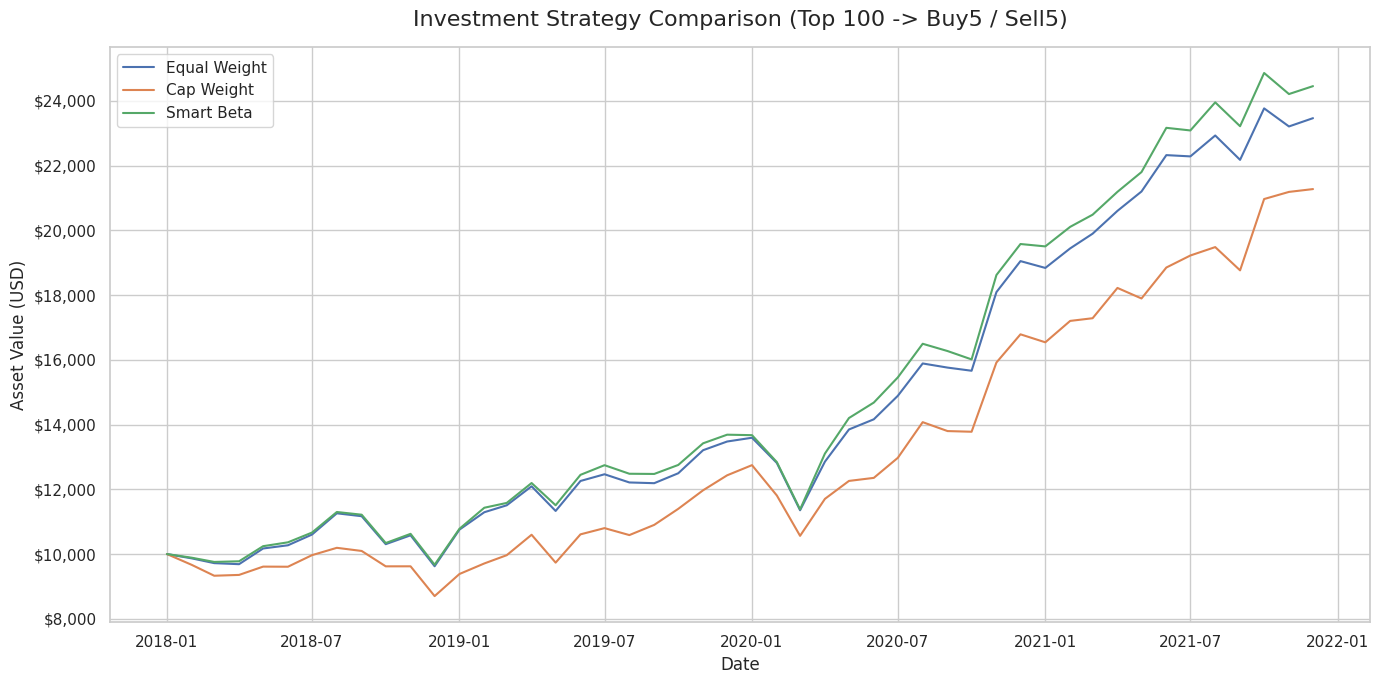

In [174]:
# =============================================================================
# [3] 결과 비교 및 시각화 (Validation)
# =============================================================================
SEED = 10000
print(">>> 전략 시뮬레이션 시작...")

d_eq, s_eq, log_eq = Open_Market_Strategy_Equal_Fixed(df_sim, 100, 5, 5, SEED)
d_cap, s_cap, log_cap = Open_Market_Strategy_Cap_Fixed(df_sim, 100, 5, 5, SEED)
d_sb, s_sb, log_sb = Open_Market_Strategy_SmartBeta_Fixed(df_sim, market_mom_dict_6m, 100, 5, 5, SEED)


# 결과 출력
print(f"\n[최종 성과 비교 (Initial: ${SEED:,.0f})]")
print(f"1. AI Equal Weight : ${s_eq[-1]:,.0f} (+{(s_eq[-1]-SEED)/SEED*100:.1f}%)")
print(f"2. AI Cap Weight   : ${s_cap[-1]:,.0f} (+{(s_cap[-1]-SEED)/SEED*100:.1f}%)")
print(f"3. AI Smart Beta   : ${s_sb[-1]:,.0f} (+{(s_sb[-1]-SEED)/SEED*100:.1f}%)")


# 그래프
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

plt.plot(pd.to_datetime(d_eq), s_eq, label='Equal Weight')
plt.plot(pd.to_datetime(d_cap), s_cap, label='Cap Weight')
plt.plot(pd.to_datetime(d_sb), s_sb, label='Smart Beta')

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.title('Investment Strategy Comparison (Top 100 -> Buy5 / Sell5)', fontsize=16, pad=15)
plt.ylabel('Asset Value (USD)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
# 2021년 데이터만 추출해서 확인
def check_2021_performance(df, n_start=50):
    # 2021년 1월 ~ 12월 데이터
    df_2021 = df[df['date'].dt.year == 2021].copy()

    # AI 모델이 가장 좋다고(pred_ret 상위) 뽑은 종목들
    # 매달 Top 50개를 뽑아서 평균 수익률 확인
    monthly_performance = []

    for ym in df_2021['yyyy_mm'].unique():
        curr = df_2021[df_2021['yyyy_mm'] == ym]

        # AI가 뽑은 Top 50
        picks = curr.nlargest(n_start, 'pred_ret')

        # 이 달의 실제 성과 (평균)
        avg_return = picks['true_ret'].mean()

        # 최악의 종목 3개 확인
        worst_stocks = picks.nsmallest(3, 'true_ret')[['ticker', 'true_ret']]
        worst_str = ", ".join([f"{r.ticker}({r.true_ret:.1%})" for r in worst_stocks.itertuples()])

        monthly_performance.append({
            'date': ym,
            'model_return': avg_return,
            'worst_picks': worst_str
        })

    return pd.DataFrame(monthly_performance)

# 실행 및 확인
df_debug_2021 = check_2021_performance(df_sim)
print(df_debug_2021)

       date  model_return                               worst_picks
0   2021-01      0.474056     GPN(-18.1%), FIS(-12.7%), LYFT(-9.5%)
1   2021-02      0.052987   GME(-68.7%), PLUG(-23.4%), INCY(-12.4%)
2   2021-03      0.020204  SNAP(-20.4%), DDOG(-12.7%), HUBS(-11.8%)
3   2021-04      0.040000    PLUG(-20.5%), ENPH(-14.1%), AAL(-9.1%)
4   2021-05      0.020348  ETSY(-17.1%), PAYC(-14.3%), TSLA(-11.9%)
5   2021-06      0.085176        UPST(-15.7%), CFG(-8.1%), J(-6.1%)
6   2021-07     -0.010220    AMC(-34.7%), PINS(-25.4%), GME(-24.8%)
7   2021-08      0.068968      ROKU(-17.7%), MAR(-7.4%), RNG(-5.6%)
8   2021-09     -0.063647     GME(-19.6%), TXG(-17.2%), WAT(-13.7%)
9   2021-10      0.081818   PINS(-12.4%), MRNA(-10.3%), ALGN(-6.2%)
10  2021-11      0.004518  TWTR(-17.9%), HZNP(-13.5%), YUMC(-12.0%)
11  2021-12      0.031689     GME(-24.4%), SQ(-22.5%), ETSY(-20.3%)


In [81]:
# 2021년 데이터만 추출해서 확인
def check_2021_performance(df, n_start=50):
    # 2021년 1월 ~ 12월 데이터
    df_2021 = df[df['date'].dt.year == 2021].copy()

    # AI 모델이 가장 좋다고(pred_ret 상위) 뽑은 종목들
    # 매달 Top 50개를 뽑아서 평균 수익률 확인
    monthly_performance = []

    for ym in df_2021['yyyy_mm'].unique():
        curr = df_2021[df_2021['yyyy_mm'] == ym]

        # AI가 뽑은 Top 50
        picks = curr.nlargest(n_start, 'pred_ret')

        # 이 달의 실제 성과 (평균)
        avg_return = picks['true_ret'].mean()

        # 최악의 종목 3개 확인
        best_stocks = picks.nlargest(3, 'true_ret')[['ticker', 'true_ret']]
        best_str = ", ".join([f"{r.ticker}({r.true_ret:.1%})" for r in best_stocks.itertuples()])

        monthly_performance.append({
            'date': ym,
            'model_return': avg_return,
            'best_picks': best_str
        })

    return pd.DataFrame(monthly_performance)

# 실행 및 확인
df_debug_2021 = check_2021_performance(df_sim)
print(df_debug_2021)

       date  model_return                              best_picks
0   2021-01      0.474056  GME(1625.1%), AMC(525.5%), PLUG(86.3%)
1   2021-02      0.052987    HUBS(38.4%), OXY(32.7%), HZNP(25.4%)
2   2021-03      0.020204     BA(20.1%), EXPD(17.3%), BURL(15.4%)
3   2021-04      0.040000      NET(20.6%), WFC(15.3%), TXT(14.6%)
4   2021-05      0.020348     NLOK(28.0%), BKR(22.4%), CLR(20.0%)
5   2021-06      0.085176    AMC(117.0%), ROKU(32.5%), NET(29.0%)
6   2021-07     -0.010220     DXCM(20.7%), YUM(14.2%), DPZ(12.6%)
7   2021-08      0.068968     UPST(89.7%), GME(35.5%), AMC(27.3%)
8   2021-09     -0.063647      TSLA(5.4%), DXCM(3.3%), ORLY(2.9%)
9   2021-10      0.081818    TSLA(43.7%), UNP(23.2%), HUBS(19.8%)
10  2021-11      0.004518    AMD(31.7%), NVDA(27.8%), AAPL(10.5%)
11  2021-12      0.031689    VRTX(17.5%), MKTX(16.6%), WAT(13.6%)


#### **임계값 O**
매도(sell) 5, 매수(buy) 5

In [129]:
# =============================================================================
# [1] 데이터 준비 (Data Setup)
# =============================================================================
# 1. 메인 데이터 로드
df_sim = final_df2.copy() # 또는 final_df2
df_sim['date'] = pd.to_datetime(df_sim['date'])
df_sim['yyyy_mm'] = df_sim['date'].dt.strftime('%Y-%m')
df_sim['me'] = df_sim['me'].fillna(0)

# 2. 유니버스 필터링 (Top 500)
top500_tickers = df_sim.groupby('ticker')['me'].mean().nlargest(500).index
df_sim = df_sim[df_sim['ticker'].isin(top500_tickers)].copy()

# 3. 시장 모멘텀 계산 (200일 ≈ 6개월)
if 'dSP500' in temp_fm_filtered.columns:
    sp500_data = temp_fm_filtered[['date', 'dSP500']].drop_duplicates('date').set_index('date')
    # 6개월 누적 수익률
    market_mom_series = (1 + sp500_data['dSP500']).rolling(6).apply(np.prod, raw=True) - 1
else:
    print("Warning: S&P500 data missing. Using Portfolio Average.")
    market_proxy = df_sim.groupby('date')['true_ret'].mean()
    market_mom_series = (1 + market_proxy).rolling(6).apply(np.prod, raw=True) - 1

# 딕셔너리 변환 (Key: 'yyyy-mm')
market_mom_dict_6m = market_mom_series.groupby(market_mom_series.index.strftime('%Y-%m')).last().to_dict()

print(f"데이터 준비 완료: {len(top500_tickers)}개 종목 / 6개월 추세 적용")

데이터 준비 완료: 500개 종목 / 6개월 추세 적용


In [166]:
def Open_Market_Strategy_Equal(df,
                               n_start=100,
                               n_sell=5,
                               n_buy=5,
                               sell_threshold=0.0,
                               initial_seed=10000):

    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['yyyy_mm'] = df['date'].dt.strftime('%Y-%m')
    df = df.sort_values('date')

    ym_list = sorted(df['yyyy_mm'].unique())
    start_ym = ym_list[0]

    # =====================================================================
    # 0. 초기 매수 (T0) — top 100
    # =====================================================================
    df_start = df[df['yyyy_mm'] == start_ym].copy()
    initial_list = df_start.nlargest(n_start, 'pred_ret')['ticker'].tolist()

    # 포인트 = 1씩 부여 (균등)
    portfolio = {t: 1.0 for t in initial_list}

    current_seed = initial_seed
    history_date = [start_ym]
    history_seed = [current_seed]

    trade_logs = [
        {"date": start_ym, "action": "Initial Buy", "ticker": t}
        for t in initial_list
    ]

    # =====================================================================
    # 1. 리밸런싱 루프 (T1 ~ )
    # =====================================================================
    for i in range(1, len(ym_list)):

        ym = ym_list[i]

        # 보유 종목
        tickers = list(portfolio.keys())
        df_curr = df[(df['yyyy_mm'] == ym) &
                     (df['ticker'].isin(tickers))].copy()

        # -----------------------------
        # [A] 포트폴리오 수익률 계산
        # -----------------------------
        if not df_curr.empty:
            df_curr.loc[:, 'units'] = df_curr['ticker'].map(portfolio)
            total_units = df_curr['units'].sum()
            df_curr.loc[:, 'weight'] = df_curr['units'] / total_units

            port_ret = (df_curr['true_ret'] * df_curr['weight']).sum()
            current_seed *= (1 + port_ret)

        history_date.append(ym)
        history_seed.append(current_seed)

        # -----------------------------
        # [B] 리밸런싱
        # -----------------------------
        if df_curr.empty:
            continue

        df_curr.loc[:, 'ranking_score'] = df_curr['pred_ret']

        # 하위 n_sell 후보
        sell_candidates = df_curr.nsmallest(n_sell, 'ranking_score')

        # threshold 조건 충족한 애만 매도
        actual_sells = sell_candidates[
            sell_candidates['ranking_score'] < sell_threshold
        ]['ticker'].tolist()

        freed_points = len(actual_sells)   # 매도한 만큼 포인트 생성

        # 실제 매도 실행
        for t in actual_sells:
            portfolio.pop(t, None)
            trade_logs.append({"date": ym, "action": "Sell", "ticker": t})

        # =================================================================
        # [C] 매수: "매도한 개수만큼만" 매수
        # =================================================================
        n_actual_buy = freed_points     # 매도 개수만큼만 신규 매수

        if n_actual_buy > 0:

            df_market = df[df['yyyy_mm'] == ym].copy()
            candidates = df_market[~df_market['ticker'].isin(portfolio.keys())]

            buy_list = candidates.nlargest(n_actual_buy, 'pred_ret')['ticker'].tolist()

            # 1포인트씩 균등 배분
            for t in buy_list:
                portfolio[t] = portfolio.get(t, 0) + 1.0
                trade_logs.append({"date": ym, "action": "Buy", "ticker": t})

        # =================================================================

    return history_date, history_seed, pd.DataFrame(trade_logs)


In [167]:
def Open_Market_Strategy_Cap(df, n_start=100, n_sell=5, sell_threshold=0.0, initial_seed=10000):
    df = df.copy()
    ym_list = sorted(df['yyyy_mm'].unique())
    start_ym = ym_list[0]

    trade_logs = []

    # --- 초기 포트폴리오 생성 (T0) ---
    df_start = df[df['yyyy_mm'] == start_ym]
    top_n_df = df_start.nlargest(n_start, 'pred_ret').copy()

    total_cap = top_n_df['me'].sum()
    top_n_df['points'] = (top_n_df['me'] / total_cap) * n_start
    portfolio = dict(zip(top_n_df['ticker'], top_n_df['points']))

    for ticker in portfolio:
        trade_logs.append({'date': start_ym, 'action': 'Initial Buy', 'ticker': ticker})

    current_seed = initial_seed
    history_date = [start_ym]
    history_seed = [current_seed]

    # --- 월별 리밸런싱 시작 (T1~) ---
    for i in range(1, len(ym_list)):
        ym = ym_list[i]

        my_tickers = list(portfolio.keys())
        df_curr = df[(df['yyyy_mm'] == ym) & (df['ticker'].isin(my_tickers))].copy()

        if df_curr.empty:
            history_date.append(ym)
            history_seed.append(current_seed)
            continue

        # [A] 포트폴리오 수익률 적용
        total_points = sum(portfolio.values())
        df_curr['unit'] = df_curr['ticker'].map(portfolio)
        df_curr['weight'] = df_curr['unit'] / total_points
        port_ret = (df_curr['true_ret'] * df_curr['weight']).sum()
        current_seed *= (1 + port_ret)

        history_date.append(ym)
        history_seed.append(current_seed)

        # [B] 리밸런싱 — 임계값 적용
        df_curr['ranking_score'] = df_curr['pred_ret']

        # threshold 아래 종목들
        below_th = df_curr[df_curr['ranking_score'] < sell_threshold]

        # 그 중 score 낮은 순으로 최대 n_sell개
        actual_sells = below_th.nsmallest(n_sell, 'ranking_score')['ticker'].tolist()

        # 포인트 회수
        freed_points = sum([portfolio[t] for t in actual_sells]) if actual_sells else 0

        # 실제 매도 반영
        for ticker in actual_sells:
            del portfolio[ticker]
            trade_logs.append({'date': ym, 'action': 'Sell', 'ticker': ticker})

        n_sold = len(actual_sells)

        # 아무것도 매도 안 했으면 여기서 끝
        if n_sold == 0:
            continue

        # [C] 신규 매수 n_sold개
        df_market = df[df['yyyy_mm'] == ym]
        candidate_pool = df_market[~df_market['ticker'].isin(portfolio.keys())]

        buys = candidate_pool.nlargest(n_sold, 'pred_ret').copy()

        total_new_cap = buys['me'].sum()
        if total_new_cap == 0:
            buys['alloc'] = freed_points / n_sold
        else:
            buys['alloc'] = (buys['me'] / total_new_cap) * freed_points

        for _, row in buys.iterrows():
            portfolio[row['ticker']] = row['alloc']
            trade_logs.append({'date': ym, 'action': 'Buy', 'ticker': row['ticker']})

    return history_date, history_seed, pd.DataFrame(trade_logs)


In [148]:
def get_scored_data_smart(d_data, momentum):
    d = d_data.copy()
    d['adj_beta'] = d['Beta'].fillna(1.0).clip(lower=0.5)

    std_p = d['pred_ret'].std(ddof=0) or 1.0
    std_b = d['adj_beta'].std(ddof=0) or 1.0

    d['z_p'] = (d['pred_ret'] - d['pred_ret'].mean()) / std_p
    d['z_b'] = (d['adj_beta'] - d['adj_beta'].mean()) / std_b

    # 상승장(>0): 베타 (0.3) / 하락장: 방어(-0.7)
    if momentum > 0: d['score'] = d['z_p'] + 0.3 * d['z_b']
    else:            d['score'] = d['z_p'] - 0.7 * d['z_b']
    return d

In [168]:
def Open_Market_Strategy_SmartBeta(df, mom_dict,
                                   n_start=100, n_sell=5,
                                   sell_threshold=-0.5,
                                   initial_seed=10000):

    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['yyyy_mm'] = df['date'].dt.strftime('%Y-%m')
    df = df.sort_values('date')

    ym_list = sorted(df['yyyy_mm'].unique().tolist())
    start_ym = ym_list[0]
    trade_logs = []

    # ===========================
    # 초기 포트폴리오 (T0)
    # ===========================
    mom = mom_dict.get(start_ym, 0)
    df_start = get_scored_data_smart(df[df['yyyy_mm'] == start_ym], mom)

    top_df = df_start.nlargest(n_start, 'score').copy()
    s_min, s_max = top_df['score'].min(), top_df['score'].max()
    scale = (top_df['score'] - s_min) / (s_max - s_min + 1e-9) + 0.1
    top_df['p'] = (scale / scale.sum()) * n_start

    portfolio = dict(zip(top_df['ticker'], top_df['p']))

    for t in portfolio.keys():
        trade_logs.append({'date': start_ym, 'action': 'Initial Buy', 'ticker': t})

    current_seed = initial_seed
    history_date = [start_ym]
    history_seed = [current_seed]

    # ===========================
    # 월별 리밸런싱 (T1~)
    # ===========================
    for i in range(1, len(ym_list)):
        ym = ym_list[i]
        my_tickers = list(portfolio.keys())

        df_curr = df[(df['yyyy_mm'] == ym) & (df['ticker'].isin(my_tickers))].copy()
        if df_curr.empty:
            history_date.append(ym)
            history_seed.append(current_seed)
            continue

        # -------- (A) 수익률 계산 --------
        total_units = sum(portfolio.values())
        df_curr['units'] = df_curr['ticker'].map(portfolio)
        df_curr['weight'] = df_curr['units'] / total_units

        port_ret = (df_curr['true_ret'] * df_curr['weight']).sum()
        current_seed *= (1 + port_ret)

        history_date.append(ym)
        history_seed.append(current_seed)

        # -------- (B) 리밸런싱 --------
        mom = mom_dict.get(ym, 0)
        df_scored = get_scored_data_smart(df_curr, mom)

        # 현재 보유 종목만
        hold_df = df_scored[df_scored['ticker'].isin(my_tickers)]

        # ① 매도 후보 5개
        sell_candidates = hold_df.nsmallest(n_sell, 'score')

        # ② 실제 매도 = threshold 조건
        actual_sells = sell_candidates[
            sell_candidates['score'] < sell_threshold
        ]['ticker'].tolist()

        actual_sell_count = len(actual_sells)
        if actual_sell_count == 0:
            continue  # 매도X → 매수도 X

        # 매도 실행
        for t in actual_sells:
            portfolio.pop(t, None)
            trade_logs.append({'date': ym, 'action': 'Sell', 'ticker': t})

        # -------- ③ 매수: 실제 매도한 개수만큼 --------
        cand = get_scored_data_smart(df[df['yyyy_mm'] == ym], mom)
        cand = cand[~cand['ticker'].isin(portfolio.keys())]

        buy_df = cand.nlargest(actual_sell_count, 'score').copy()

        # 점수 비례 배분
        s_min, s_max = buy_df['score'].min(), buy_df['score'].max()
        scale = (buy_df['score'] - s_min) / (s_max - s_min + 1e-9) + 0.1
        buy_df['p'] = (scale / scale.sum()) * actual_sell_count

        for r in buy_df.itertuples():
            portfolio[r.ticker] = portfolio.get(r.ticker, 0) + r.p
            trade_logs.append({'date': ym, 'action': 'Buy', 'ticker': r.ticker})

    return history_date, history_seed, pd.DataFrame(trade_logs)


>>> 전략 비교 시뮬레이션 시작...

[최종 자산] (초기: $10,000)
1. AI Equal : $29,757 (197.6%)
2. AI Cap   : $22,046 (120.5%)
3. AI Smart : $35,583 (255.8%)


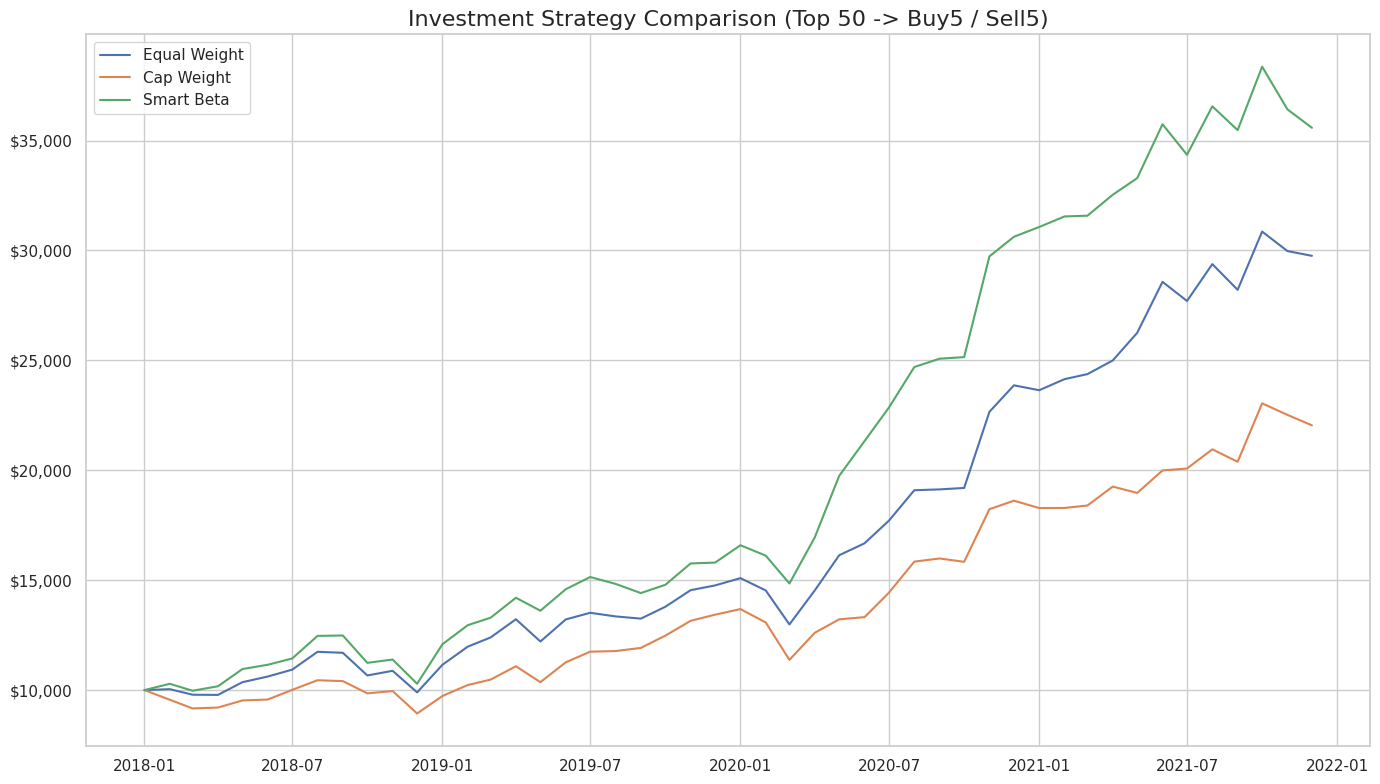

In [173]:
# =============================================================================
# [3] 실행 및 시각화 (Action)
# =============================================================================
INIT_SEED = 10000
N_START = 50
N_SELL = 5
N_BUY = 5

print(">>> 전략 비교 시뮬레이션 시작...")

d_eq2, s_eq2, log_eq2 = Open_Market_Strategy_Equal(df_sim, N_START, N_SELL, 0, INIT_SEED)
d_cap2, s_cap2, log_cap2 = Open_Market_Strategy_Cap(df_sim, N_START, N_SELL, 0, INIT_SEED)
d_sb2, s_sb2, log_sb2 = Open_Market_Strategy_SmartBeta(df_sim, market_mom_dict_6m, N_START, N_SELL, -0.5, INIT_SEED)


# 결과
print(f"\n[최종 자산] (초기: ${INIT_SEED:,.0f})")
print(f"1. AI Equal : ${s_eq2[-1]:,.0f} ({(s_eq2[-1]-INIT_SEED)/INIT_SEED*100:.1f}%)")
print(f"2. AI Cap   : ${s_cap2[-1]:,.0f} ({(s_cap2[-1]-INIT_SEED)/INIT_SEED*100:.1f}%)")
print(f"3. AI Smart : ${s_sb2[-1]:,.0f} ({(s_sb2[-1]-INIT_SEED)/INIT_SEED*100:.1f}%)")

# 그래프
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

plt.plot(pd.to_datetime(d_eq), s_eq2, label='Equal Weight')
plt.plot(pd.to_datetime(d_cap), s_cap2, label='Cap Weight')
plt.plot(pd.to_datetime(d_sb), s_sb2, label='Smart Beta')

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.title('Investment Strategy Comparison (Top 50 -> Buy5 / Sell5)', fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()

### **단순 수익률과 비교**

#### **비교 함수**

In [175]:
def calculate_buy_and_hold(df, target_tickers, initial_seed=100000, weight_type='equal'):
    """
    특정 종목 리스트를 시뮬레이션 시작일에 매수하여 끝까지 보유(Buy & Hold)하는 함수
    - weight_type='equal': 균등 비중 매수
    - weight_type='cap': 시가총액 비례 매수 (시작일 기준)
    """
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['yyyy_mm'] = df['date'].dt.strftime('%Y-%m')
    df = df.sort_values('date')

    ym_list = df['yyyy_mm'].unique().tolist()
    start_ym = ym_list[0]

    # 시작 시점 데이터
    df_start = df[(df['yyyy_mm'] == start_ym) & (df['ticker'].isin(target_tickers))].copy()

    # 포트폴리오 초기 구성
    if weight_type == 'cap' and 'me' in df_start.columns:
        total_cap = df_start['me'].sum()
        df_start['alloc'] = (df_start['me'] / total_cap) * initial_seed
    else:
        # 균등 배분
        df_start['alloc'] = initial_seed / len(df_start)

    # 각 종목별 현재 평가금액 딕셔너리 {ticker: amount}
    portfolio = dict(zip(df_start['ticker'], df_start['alloc']))

    current_total_value = initial_seed

    # --- FIX: T0 시작점 기록 ---
    history_date = [start_ym]
    history_seed = [current_total_value]

    # --- FIX: 루프를 두 번째 달(i=1)부터 시작 ---
    for i in range(1, len(ym_list)):
        ym = ym_list[i] # T_i

        # 현재 보유 중인 종목들의 이번 달 수익률 데이터 가져오기
        my_tickers = list(portfolio.keys())
        df_curr = df[(df['yyyy_mm'] == ym) & (df['ticker'].isin(my_tickers))]

        # 수익률 적용 (개별 종목 평가금액 갱신)
        if not df_curr.empty:
            for _, row in df_curr.iterrows():
                tik = row['ticker']
                ret = row['true_ret']
                if tik in portfolio:
                    portfolio[tik] = portfolio[tik] * (1 + ret)

        # 이번 달 총 평가금액 합산
        current_total_value = sum(portfolio.values())

        history_date.append(ym)
        history_seed.append(current_total_value)

    return history_date, history_seed

In [176]:
start_date = sorted(df_sim['date'].unique())[0]
df_start = df_sim[df_sim['date'] == start_date]

target_benchmark_tickers = df_start.nlargest(100, 'me')['ticker'].tolist()

In [177]:
d_bm_eq, s_bm_eq = calculate_buy_and_hold(df_sim, target_benchmark_tickers, 10000, weight_type='equal')

d_bm_cap, s_bm_cap = calculate_buy_and_hold(df_sim, target_benchmark_tickers, 10000, weight_type='cap')

In [178]:
print(f"1. BM Equal : ${s_bm_eq[-1]:,.0f} ({(s_bm_eq[-1]-INIT_SEED)/INIT_SEED*100:.1f}%)")
print(f"2. BM Cap   : ${s_bm_cap[-1]:,.0f} ({(s_bm_cap[-1]-INIT_SEED)/INIT_SEED*100:.1f}%)")

1. BM Equal : $16,697 (67.0%)
2. BM Cap   : $18,646 (86.5%)


In [182]:
def calculate_low_vol_benchmark(df, initial_seed=10000):
    """
    Low Volatility Benchmark (Inverse Beta Weight)
    - T0에서 시총 Top 100 선택
    - 베타 역수로 가중치 결정
    - Buy & Hold 방식
    """

    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['yyyy_mm'] = df['date'].dt.strftime('%Y-%m')
    df = df.sort_values('date')

    ym_list = df['yyyy_mm'].unique().tolist()
    start_ym = ym_list[0]

    # ─────────────────────────
    # 1. 시작 시점 종목 선정 (Top 100 by Market Cap)
    # ─────────────────────────
    df_start = df[df['yyyy_mm'] == start_ym].copy()
    top_df = df_start.nlargest(100, 'me').copy()

    # ─────────────────────────
    # 2. Inverse Beta Weight
    # ─────────────────────────
    top_df['adj_beta'] = top_df['Beta'].fillna(1.0).clip(lower=0.5)
    top_df['inv_beta'] = 1 / top_df['adj_beta']

    total_inv = top_df['inv_beta'].sum()
    top_df['alloc'] = (top_df['inv_beta'] / total_inv) * initial_seed

    # 포트폴리오 = 평가금액
    portfolio = dict(zip(top_df['ticker'], top_df['alloc']))

    # ─────────────────────────
    # 3. Buy & Hold 성과 계산
    # ─────────────────────────
    current_total = initial_seed
    history_date = [start_ym]
    history_seed = [current_total]

    for i in range(1, len(ym_list)):
        ym = ym_list[i]
        df_curr = df[(df['yyyy_mm'] == ym) & (df['ticker'].isin(portfolio.keys()))]

        if not df_curr.empty:
            for _, row in df_curr.iterrows():
                tik = row['ticker']
                ret = row['true_ret']
                portfolio[tik] *= (1 + ret)

        current_total = sum(portfolio.values())
        history_date.append(ym)
        history_seed.append(current_total)

    return history_date, history_seed


In [183]:
d_bm_lowvol, s_bm_lowvol = calculate_low_vol_benchmark(df_sim, SEED)

In [184]:
print(f"3. BM low vol   : ${s_bm_lowvol[-1]:,.0f} ({(s_bm_lowvol[-1]-INIT_SEED)/INIT_SEED*100:.1f}%)")

3. BM low vol   : $18,157 (81.6%)


#### **비교 결과**

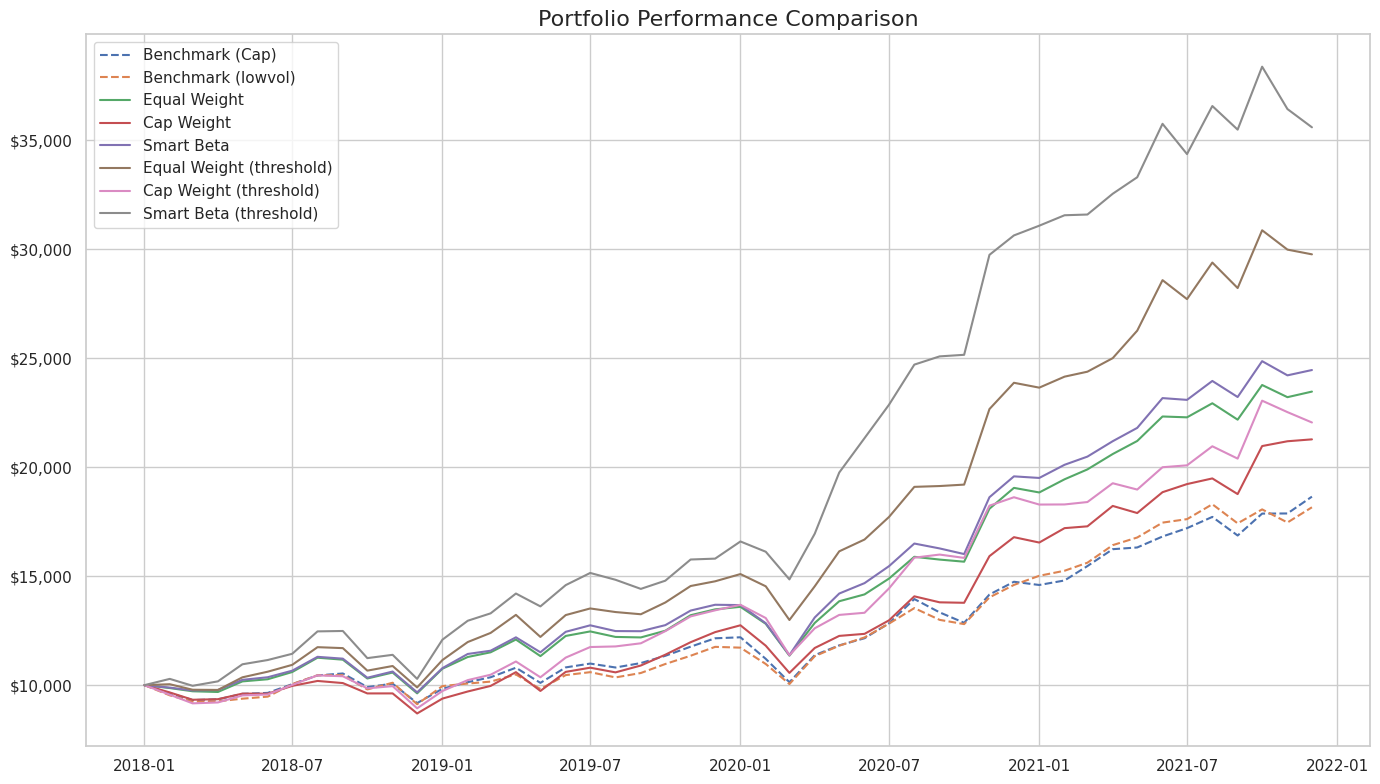

In [187]:
INIT_SEED = 10000
N_START = 50
N_SELL = 5
N_BUY = 5


# 그래프
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

plt.plot(pd.to_datetime(d_bm_cap), s_bm_cap, label='Benchmark (Cap)', linestyle="--")
plt.plot(pd.to_datetime(d_bm_lowvol), s_bm_lowvol, label='Benchmark (lowvol)' , linestyle="--")
plt.plot(pd.to_datetime(d_eq), s_eq, label='Equal Weight')
plt.plot(pd.to_datetime(d_cap), s_cap, label='Cap Weight')
plt.plot(pd.to_datetime(d_sb), s_sb, label='Smart Beta')
plt.plot(pd.to_datetime(d_eq2), s_eq2, label='Equal Weight (threshold)')
plt.plot(pd.to_datetime(d_cap2), s_cap2, label='Cap Weight (threshold)')
plt.plot(pd.to_datetime(d_sb2), s_sb2, label='Smart Beta (threshold)')

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.title('Portfolio Performance Comparison', fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()

### **최적 포트폴리오 분석**

#### **함수**

In [188]:
import pandas as pd
import numpy as np

# [주의] 이 함수를 사용하려면, 시뮬레이션 결과를 담는 'results' 딕셔너리와 'df_sim' 데이터프레임이 필요합니다.

def analyze_performance_drivers(df_all, results, target_strategy_name, SEED):
    """
    특정 전략의 승리 요인(대박 종목, 적중률, 최고의 순간)을 분석하는 함수
    - df_all: 전체 시뮬레이션 데이터 (df_sim)
    - results: 실행 결과 딕셔너리 (예: {'Smart Beta': {'dates': d_sb, 'seeds': s_sb, 'log': df_log_sb}})
    - target_strategy_name: 분석할 전략 이름 (키값)
    - SEED: 초기 투자 금액 (수익률 역산 시 필요)
    """
    if target_strategy_name not in results:
        print(f"Error: '{target_strategy_name}' 전략의 결과가 없습니다.")
        return

    data = results[target_strategy_name]
    log_df = data['log']

    # --- 1. 대박 종목 분석 (2018년 전체 기간의 실제 수익률 기준) ---

    # [주의] 2018년 전체 기간 수익률을 계산합니다.
    df_period = df_all.copy()

    # 🚨 FIX: 연간 수익률 계산 로직
    # 현재 데이터셋은 월별이므로, 연간 계산을 위해서는 날짜가 모두 포함되어야 합니다.
    df_period['ret_plus_1'] = df_period['true_ret'] + 1
    # 종목별 누적 수익률 계산 (전체 시뮬레이션 기간 기준)
    stock_total_ret = df_period.groupby('ticker')['ret_plus_1'].prod() - 1

    # 2. 내 전략이 매수한 종목들 추출
    bought_tickers = log_df[log_df['action'].isin(['Buy', 'Initial Buy'])]['ticker'].unique()

    # 3. 매수한 종목들의 성적표 매칭
    my_picks_df = pd.DataFrame({'ticker': bought_tickers})
    # [수정] actual_year_ret -> actual_total_ret (전체 시뮬 기간)
    my_picks_df = my_picks_df.merge(stock_total_ret.rename('actual_total_ret'), on='ticker', how='left')

    # 분석 1: 신의 한 수 (내가 산 것 중 가장 수익률이 높았던 종목 Top 10)
    top_contributors = my_picks_df.sort_values(by='actual_total_ret', ascending=False).head(10)

    # 분석 2: 적중률 (산 종목 중 +수익인 비율)
    total_bought = len(my_picks_df)
    # [수정] 실제 연간 수익률이 0보다 큰 종목 필터링
    # 주의: 여기서 total_bought는 '중복되지 않은 매수 종목의 총 수'입니다.
    winners = len(my_picks_df[my_picks_df['actual_total_ret'] > 0])
    hit_rate = (winners / total_bought) * 100 if total_bought > 0 else 0

    # --- 4. 최고의 순간 분석 (월별 수익률 역산) ---

    seeds = data['seeds']
    dates = data['dates']
    monthly_rets = []

    # 🚨 FIX: T0 시작값을 맨 앞에 추가하여 정확한 월별 수익률 계산 (Logarithmic Return Calculation)
    # seeds[0]은 T0 (10000)이므로, seeds 자체를 사용하면 됨.
    full_seeds = seeds

    for i in range(1, len(full_seeds)):
        # (V_i - V_{i-1}) / V_{i-1}
        ret = (full_seeds[i] - full_seeds[i-1]) / full_seeds[i-1]
        monthly_rets.append({'date': dates[i], 'monthly_return': ret}) # dates[i]는 V_i가 기록된 날짜 (T1, T2, ...)

    df_monthly = pd.DataFrame(monthly_rets)
    best_months = df_monthly.sort_values(by='monthly_return', ascending=False).head(3)

    # --- 리포트 출력 ---
    print("\n" + "="*80)
    print(f"🔎 전략 심층 분석: [{target_strategy_name}]")
    print("="*80)

    print(f"1. 종목 선정 적중률 (Hit Rate)")
    print(f"   - 총 고유 매수 종목 수 : {total_bought}개")
    print(f"   - 실제 총 기간 상승 종목  : {winners}개")
    print(f"   - 적중률          : {hit_rate:.2f}%")
    print("-" * 80)

    print(f"2. '신의 한 수' Top 10 (포트폴리오에 담았던 대박 종목들)")
    print("-" * 80)
    print(f"{'Ticker':<10} | {'총 기간 실제 수익률':<20}")
    for _, row in top_contributors.iterrows():
        print(f"{row['ticker']:<10} | {row['actual_total_ret']*100:15.2f}%")
    print("-" * 80)

    print(f"3. 결정적 순간 (수익이 폭발한 최고의 달) 💰")
    for _, row in best_months.iterrows():
        print(f"   - {row['date']} : +{row['monthly_return']*100:.2f}%")
    print("="*80)

#### **결과**

In [189]:
results = {
    'Smart Beta': {'dates': d_sb2, 'seeds': s_sb2, 'log': log_sb2},
    'Equal Weight': {'dates': d_eq2, 'seeds': s_eq2, 'log': log_eq2},
    'Cap Weight': {'dates': d_cap2, 'seeds': s_cap2, 'log': log_cap2}
}

In [190]:
# df_sim은 전체 기간 데이터 프레임입니다.
analyze_performance_drivers(df_sim, results, 'Smart Beta', SEED)
analyze_performance_drivers(df_sim, results, 'Equal Weight', SEED)
analyze_performance_drivers(df_sim, results, 'Cap Weight', SEED)


🔎 전략 심층 분석: [Smart Beta]
1. 종목 선정 적중률 (Hit Rate)
   - 총 고유 매수 종목 수 : 188개
   - 실제 총 기간 상승 종목  : 170개
   - 적중률          : 90.43%
--------------------------------------------------------------------------------
2. '신의 한 수' Top 10 (포트폴리오에 담았던 대박 종목들)
--------------------------------------------------------------------------------
Ticker     | 총 기간 실제 수익률         
TTD        |         1903.94%
TSLA       |         1597.09%
AMD        |         1299.81%
AMC        |         1183.02%
TWLO       |         1015.85%
ETSY       |          970.61%
MRNA       |          875.72%
DXCM       |          835.62%
OKTA       |          775.32%
FTNT       |          722.61%
--------------------------------------------------------------------------------
3. 결정적 순간 (수익이 폭발한 최고의 달) 💰
   - 2020-11 : +18.23%
   - 2019-01 : +17.47%
   - 2020-05 : +16.56%

🔎 전략 심층 분석: [Equal Weight]
1. 종목 선정 적중률 (Hit Rate)
   - 총 고유 매수 종목 수 : 185개
   - 실제 총 기간 상승 종목  : 166개
   - 적중률          : 89.73%
---------------------------

#### **Top10 종목 주식 그래프**

In [192]:
!pip install yfinance

In [193]:
import yfinance as yf

In [191]:
TARGET_STRATEGY = 'Smart Beta'

In [197]:
def analyze_top_contributors_price_trajectory(df_all, results, TARGET_STRATEGY):
    """
    특정 전략이 매수한 종목 중, 가장 높은 총 기간 수익률을 기록한 Top 10 종목의
    주가 궤적을 Yahoo Finance 데이터를 이용하여 시각화합니다.

    df_all: 전체 시뮬레이션 데이터 (df_sim)
    results: 실행 결과 딕셔너리
    TARGET_STRATEGY: 분석할 전략 이름 ('Smart Beta', 'Equal Weight' 등)
    """

    if TARGET_STRATEGY not in results:
        print(f"Error: '{TARGET_STRATEGY}' 전략의 결과가 없습니다.")
        return

    # ---------------------------------------------------------
    # [Step 1] Top 10 선정 (전체 시뮬레이션 기간 수익률 기준)
    # ---------------------------------------------------------
    log_df = results[TARGET_STRATEGY]['log']

    # 전략이 매수한 모든 고유 티커 추출
    bought_tickers = log_df[log_df['action'].isin(['Buy', 'Initial Buy'])]['ticker'].unique()

    # 전체 기간 동안의 종목별 실제 수익률 계산 (df_all == df_sim)
    df_all['ret_plus_1'] = df_all['true_ret'] + 1
    # 종목별 누적 수익률 (전체 기간)
    stock_total_ret = df_all.groupby('ticker')['ret_plus_1'].prod() - 1

    # 매수한 종목들의 성적표 매칭 및 Top 10 선정
    my_picks_ret = stock_total_ret[stock_total_ret.index.isin(bought_tickers)]
    my_top_10 = my_picks_ret.sort_values(ascending=False).head(10).index.tolist()

    print(f"🎯 전략 [{TARGET_STRATEGY}]의 Top 10 컨트리뷰터 선정 완료.")

    # ---------------------------------------------------------
    # [Step 2] 티커 보정 및 야후 파이낸스 다운로드 준비
    # ---------------------------------------------------------
    # 야후 파이낸스용 티커 보정 (예: AAXN -> AXON)
    my_top_10_yf = [t.replace('AAXN', 'AXON') for t in my_top_10]

    # 시작일과 종료일 설정 (df_all의 기간과 일치시키기 위해)
    start_date = df_all['date'].min().strftime('%Y-%m-%d')
    end_date = df_all['date'].max().strftime('%Y-%m-%d')

    print(f"📌 최종 주가 추적 리스트: {my_top_10_yf} (기간: {start_date} ~ {end_date})")

    # Yahoo Finance 다운로드
    try:
        # auto_adjust=True: 배당/분할 자동 반영, Close 컬럼만 사용
        stock_data = yf.download(my_top_10_yf, start=start_date, end=end_date, auto_adjust=True)['Close']
    except Exception as e:
        print(f"❌ Yahoo Finance 다운로드 실패: {e}. 라이브러리 설치 및 네트워크를 확인하세요.")
        return

    # ---------------------------------------------------------
    # [Step 3] 그래프 그리기 (지수화 및 플롯)
    # ---------------------------------------------------------

    # 지수화 (Start Date = 100)
    normalized_data = stock_data.copy()

    plt.figure(figsize=(14, 8))
    sns.set_theme(style="whitegrid")

    for ticker_yf in my_top_10_yf:
        if ticker_yf in normalized_data.columns:
            # 원본 티커 이름 복구 (수익률 매칭용)
            original_ticker = ticker_yf.replace('AXON', 'AAXN')

            # 정규화 (첫 유효값 기준 100)
            first_valid = normalized_data[ticker_yf].first_valid_index()
            if first_valid is not None:
                base_value = normalized_data.loc[first_valid, ticker_yf]
                normalized_data[ticker_yf] = (normalized_data[ticker_yf] / base_value) * 100

                # 최종 수익률 (전체 시뮬레이션 기간 기준)
                final_ret = stock_total_ret.get(original_ticker, 0) * 100

                plt.plot(normalized_data.index, normalized_data[ticker_yf],
                         label=f"{original_ticker} (Total Ret: +{final_ret:.0f}%)")

    plt.title(f"My Portfolio's Top Contributors ({TARGET_STRATEGY}) - Price Trajectory (Normalized)", fontsize=16)
    plt.ylabel("Price Index (Start=100)", fontsize=12)
    plt.xlabel("Date", fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, title="Ticker (Total Return)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 💡 사용 예시 (이 코드는 df_sim과 results 변수가 정의된 상태에서 실행해야 함)
# ---------------------------------------------------------
# analyze_top_contributors_price_trajectory(df_sim, results, 'Smart Beta')

🎯 전략 [Smart Beta]의 Top 10 컨트리뷰터 선정 완료.
📌 최종 주가 추적 리스트: ['TTD', 'TSLA', 'AMD', 'AMC', 'TWLO', 'ETSY', 'MRNA', 'DXCM', 'OKTA', 'FTNT'] (기간: 2018-01-31 ~ 2021-12-31)


[*********************100%***********************]  10 of 10 completed


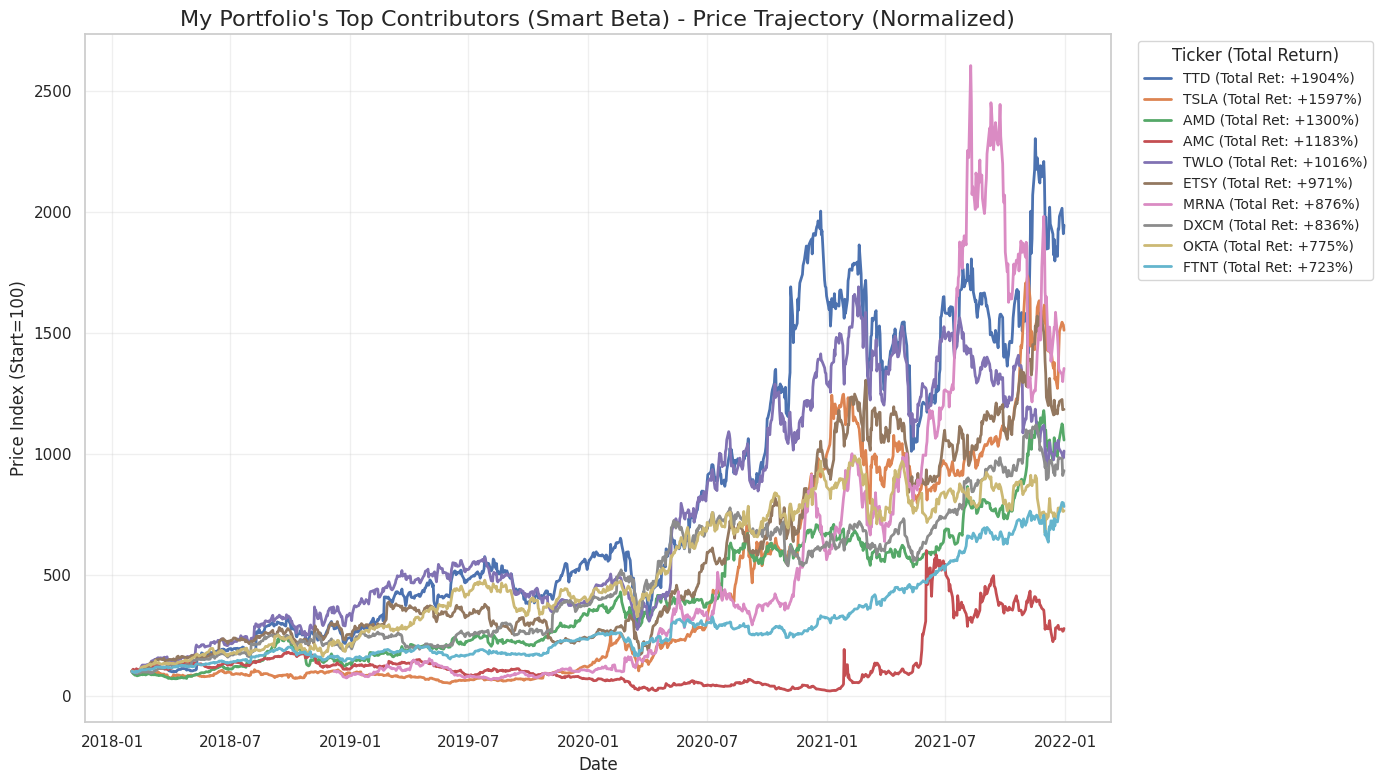

In [196]:
analyze_top_contributors_price_trajectory(df_sim, results, 'Smart Beta')

#### **기여도 Top10 종목 주식 그래프**

In [198]:
# [주의] get_scored_data_smart 함수가 정의되어 있어야 합니다. (이전 답변에 포함되어 있음)

def calculate_and_rank_trc(df, mom_dict, n_start=100, n_sell=5, n_buy=5, sell_threshold=-0.5):
    """
    Smart Beta 전략의 총 수익 기여도(TRC)를 계산하고 Top 10 종목을 반환합니다.
    """
    ym_list = sorted(df['yyyy_mm'].unique().tolist())
    current_seed = 10000.0 # 초기 자금

    # Ticker별 총 공헌도를 추적하는 딕셔너리
    trc_tracker = {}

    # --- T0 초기 포트폴리오 세팅 ---
    start_ym = ym_list[0]
    mom = mom_dict.get(start_ym, 0)
    df_start = get_scored_data_smart(df[df['yyyy_mm'] == start_ym], mom)

    top_df = df_start.nlargest(n_start, 'score').copy()
    s_min, s_max = top_df['score'].min(), top_df['score'].max()
    scale = (top_df['score'] - s_min) / (s_max - s_min + 1e-9) + 0.1
    top_df['p'] = (scale / scale.sum()) * n_start
    portfolio = dict(zip(top_df['ticker'], top_df['p']))

    # --- T1부터 TRC 계산 시작 ---
    for i in range(1, len(ym_list)):
        ym = ym_list[i]

        my_tickers = list(portfolio.keys())
        df_curr = df[(df['yyyy_mm'] == ym) & (df['ticker'].isin(my_tickers))].copy()

        if df_curr.empty: continue

        # [A] 수익률 및 공헌도 계산 (TRC)
        total_points = sum(portfolio.values())
        df_curr['units'] = df_curr['ticker'].map(portfolio)
        df_curr['weight'] = df_curr['units'] / total_points

        # 📌 TRC 핵심 계산: (이전 총 자산) * (현재 비중) * (실제 수익률)
        # ⚠️ Note: current_seed는 V_t-1 이며, TRC는 달러 기준으로 누적됩니다.
        df_curr['monthly_contribution'] = df_curr['weight'] * df_curr['true_ret'] * current_seed

        # Ticker별 기여도 누적
        for idx, row in df_curr.iterrows():
            trc_tracker[row['ticker']] = trc_tracker.get(row['ticker'], 0) + row['monthly_contribution']

        # 자산 업데이트 (다음 루프를 위해)
        port_ret = df_curr['monthly_contribution'].sum() / current_seed # 포트폴리오 수익률
        current_seed *= (1 + port_ret)

        # [B] 리밸런싱 (다음 달 P(i) 세팅)
        mom = mom_dict.get(ym, 0)
        df_scored = get_scored_data_smart(df_curr, mom)

        current_holdings = list(portfolio.keys())
        holdings_df = df_scored[df_scored['ticker'].isin(current_holdings)]

        # 매도/매수 로직 (생략: 이전 Smart Beta 함수와 동일)
        sell_candidates_df = holdings_df.nsmallest(n_sell, 'score')
        virtual_freed = sum([portfolio.get(t, 0) for t in sell_candidates_df['ticker']])
        if virtual_freed == 0: virtual_freed = float(n_sell)

        actual_sells = sell_candidates_df[sell_candidates_df['score'] < sell_threshold]['ticker'].tolist()
        for t in actual_sells:
            if t in portfolio: del portfolio[t]

        cand = df_scored[~df_scored['ticker'].isin(portfolio.keys())]
        buy_df = cand.nlargest(n_buy, 'score').copy()

        s_min, s_max = buy_df['score'].min(), buy_df['score'].max()
        scale = (buy_df['score'] - s_min) / (s_max - s_min + 1e-9) + 0.1
        buy_df['p'] = (scale / scale.sum()) * virtual_freed

        for r in buy_df.itertuples():
            portfolio[r.ticker] = portfolio.get(r.ticker, 0) + r.p

    # --- 최종 Top 10 랭킹 ---
    trc_series = pd.Series(trc_tracker)
    return trc_series.nlargest(10).index.tolist()

In [199]:
top_10_trc_tickers = calculate_and_rank_trc(df_sim, market_mom_dict_6m)

print("Smart Beta 전략의 총 수익 기여도(TRC) Top 10 종목:")
print(top_10_trc_tickers)

Smart Beta 전략의 총 수익 공헌도(TRC) Top 10 종목:
['OKTA', 'TTD', 'HUBS', 'FANG', 'ETSY', 'SNAP', 'MSFT', 'ALGN', 'KLAC', 'RNG']


📌 최종 주가 추적 리스트: ['OKTA', 'TTD', 'HUBS', 'FANG', 'ETSY', 'SNAP', 'MSFT', 'ALGN', 'KLAC', 'RNG']


[*********************100%***********************]  10 of 10 completed


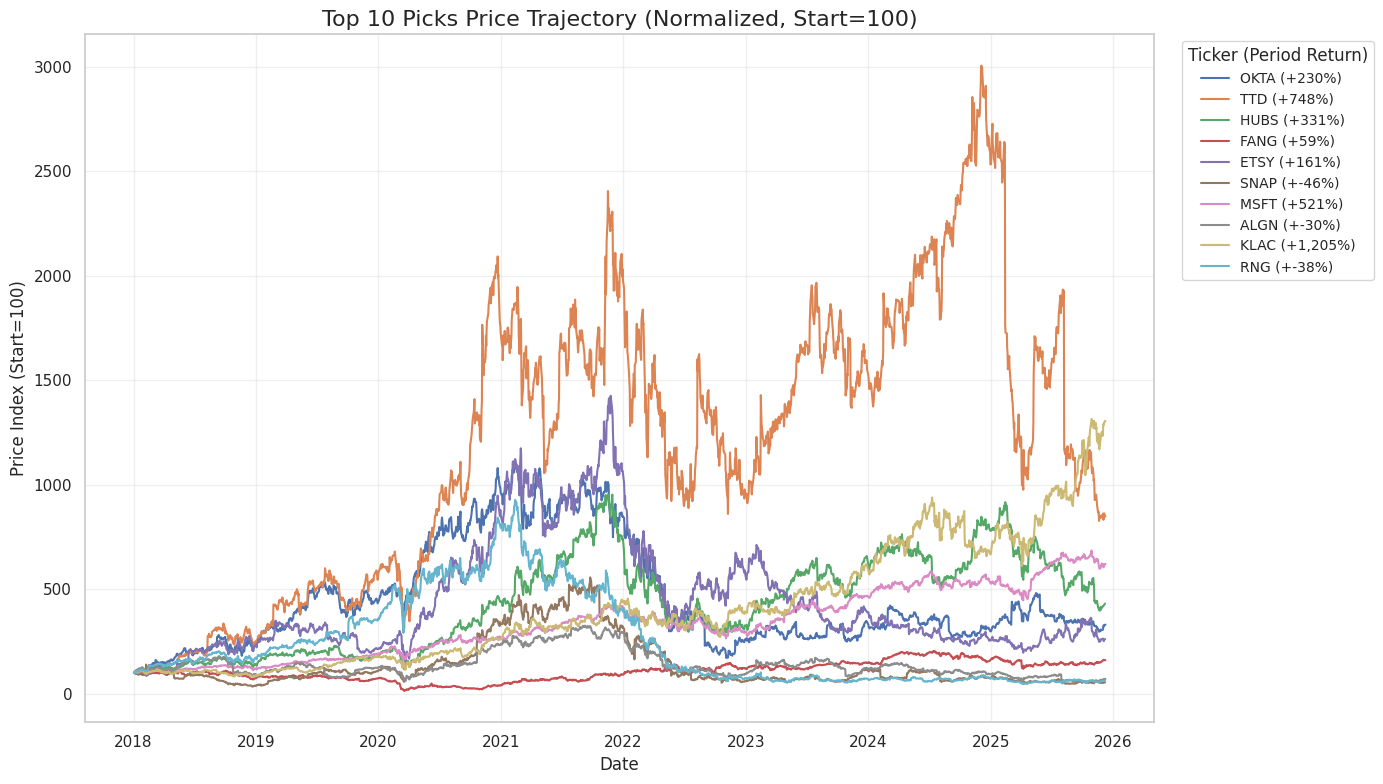

In [205]:
if 'my_top_10' not in locals():
    print("🚨 'my_top_10' 리스트가 정의되지 않았습니다. 예시 리스트로 진행합니다.")
    my_top_10 = ['OKTA', 'TTD', 'HUBS', 'FANG', 'ETSY', 'SNAP', 'MSFT', 'ALGN', 'KLAC', 'RNG']

# ---------------------------------------------------------
# [Step 1] 티커 보정 및 데이터 다운로드
# ---------------------------------------------------------
# 티커 보정 (상장폐지/변경 티커 처리)
my_top_10_yf = ['AXON' if x == 'AAXN' else x for x in my_top_10]
if 'COUP' in my_top_10_yf: my_top_10_yf.remove('COUP')

print(f"📌 최종 주가 추적 리스트: {my_top_10_yf}")

# 데이터 다운로드 (2018년 ~ 현재)
try:
    stock_data = yf.download(my_top_10_yf, start='2018-01-01', end='2025-12-31', auto_adjust=True)['Close']
except Exception as e:
    print(f"다운로드 실패: {e}")
    stock_data = pd.DataFrame()

# ---------------------------------------------------------
# [Step 2] 그래프 그리기 (지수화)
# ---------------------------------------------------------
if not stock_data.empty:
    plt.figure(figsize=(14, 8))
    sns.set_theme(style="whitegrid")

    # 지수화 (Start Date = 100으로 통일)
    normalized_data = stock_data.copy()

    for ticker in my_top_10_yf:
        if ticker in normalized_data.columns:
            # 데이터가 있는 첫 날짜 찾기 (상장일이 다를 수 있음)
            first_valid = normalized_data[ticker].first_valid_index()

            if first_valid is not None:
                base_value = normalized_data.loc[first_valid, ticker]

                # 정규화 계산
                normalized_data[ticker] = (normalized_data[ticker] / base_value) * 100

                # 기간 수익률 계산 (범례 표시용)
                last_valid = normalized_data[ticker].last_valid_index()
                final_val = normalized_data.loc[last_valid, ticker]
                period_ret = final_val - 100 # 시작이 100이므로

                plt.plot(normalized_data.index, normalized_data[ticker],
                         label=f"{ticker} (+{period_ret:,.0f}%)")

    plt.title("Top 10 Picks Price Trajectory (Normalized, Start=100)", fontsize=16)
    plt.ylabel("Price Index (Start=100)", fontsize=12)
    plt.xlabel("Date", fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, title="Ticker (Period Return)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("데이터가 없어 그래프를 그릴 수 없습니다.")